In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import os
import time

In [2]:
os.environ["CUDA_VISIBLE_DEVICES"]= str(5)

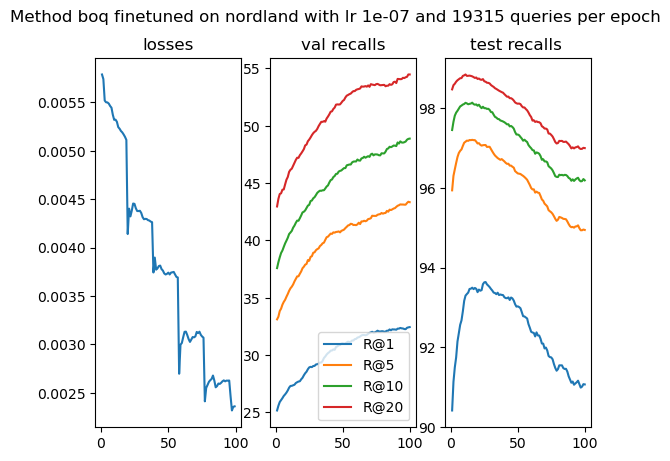

test recalls were [91.0771238  94.9514352  96.21629458 96.99913018] for the highest validation R@5
Original model results were [90.41751232 95.93360394 97.44491157 98.4633227 ] 
6
19315
average epoch took4:39:44.288395 and median: 4:46:49.897989
training backbone: original with model.eval
training aggregator: True
augmentations: True


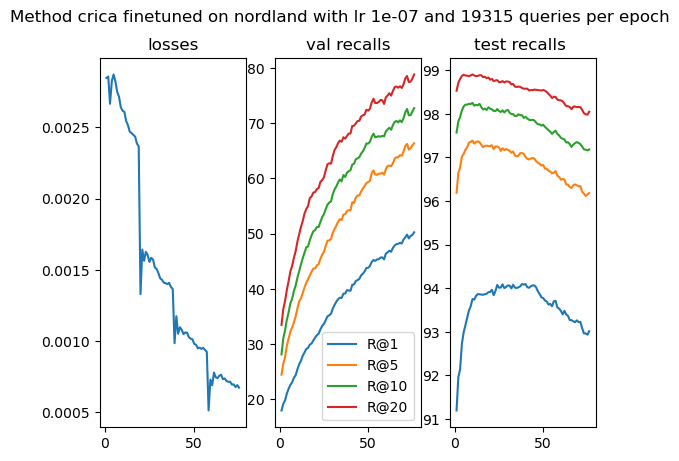

test recalls were [93.01246738 96.18367643 97.18396637 98.05015947] for the highest validation R@5
Original model results were [91.19309945 96.19092491 97.57175993 98.53218324] 
7
19315
average epoch took2:29:58.138117 and median: 2:28:20.005726
training backbone: original with model.eval
training aggregator: True
augmentations: True


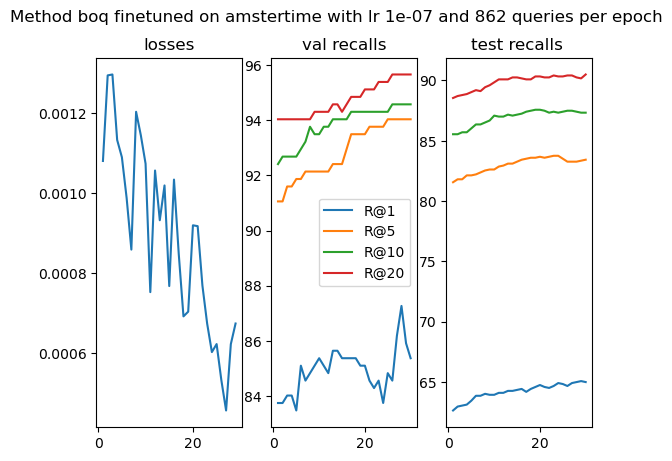

test recalls were [64.82534525 83.509342   87.40861089 90.33306255] for the highest validation R@5
Original model results were [62.6320065  81.55970755 85.54021121 88.54589764] 
7
862
average epoch took0:02:18.915246 and median: 0:02:16.237020
training backbone: original with model.eval
training aggregator: True
augmentations: True


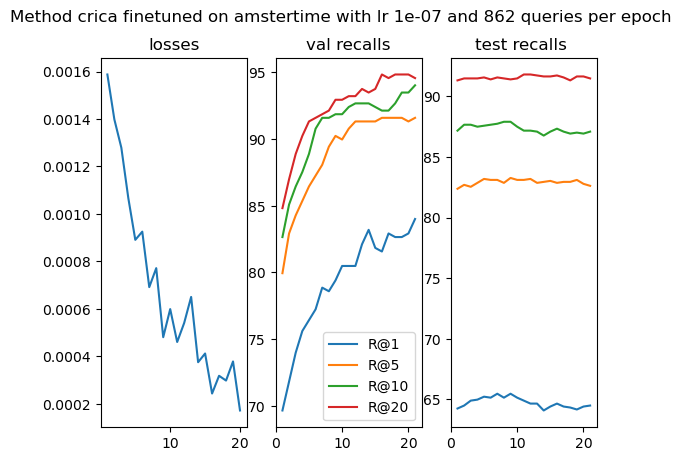

test recalls were [64.66287571 82.85946385 87.32737612 91.71405361] for the highest validation R@5
Original model results were [64.25670187 82.37205524 87.16490658 91.30787977] 
7
862
average epoch took0:01:53.362074 and median: 0:01:50.724934
training backbone: original with model.eval
training aggregator: True
augmentations: True


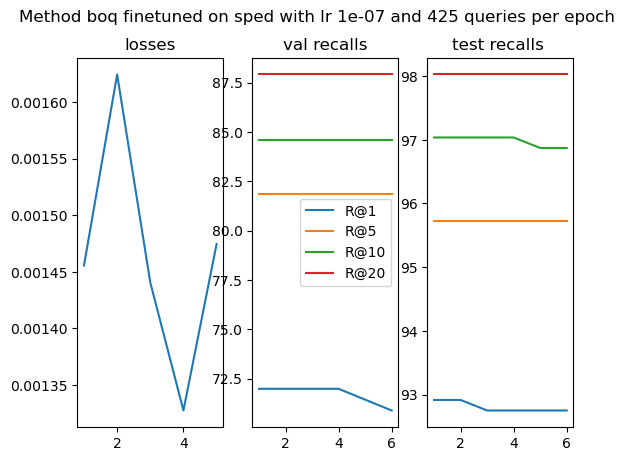

test recalls were [92.91598023 95.71663921 97.03459638 98.02306425] for the highest validation R@5
Original model results were [92.91598023 95.71663921 97.03459638 98.02306425] 
7
425
average epoch took0:01:15.578415 and median: 0:01:17.334048
training backbone: original with model.eval
training aggregator: True
augmentations: True


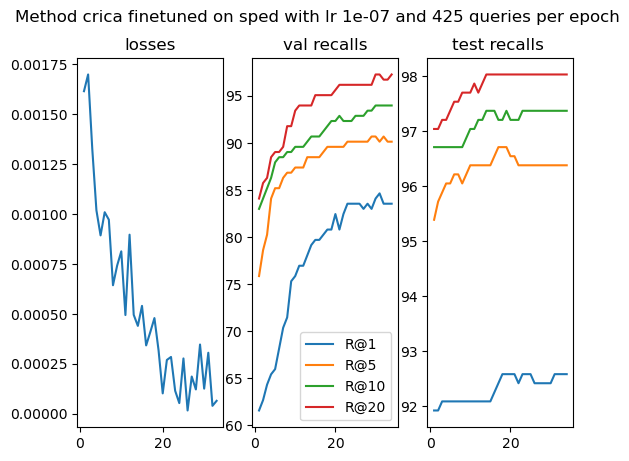

test recalls were [92.42174629 96.37561779 97.36408567 98.02306425] for the highest validation R@5
Original model results were [91.92751236 95.38714992 96.70510708 97.03459638] 
7
425
average epoch took0:00:57.029528 and median: 0:00:55.741016
training backbone: original with model.eval
training aggregator: True
augmentations: True


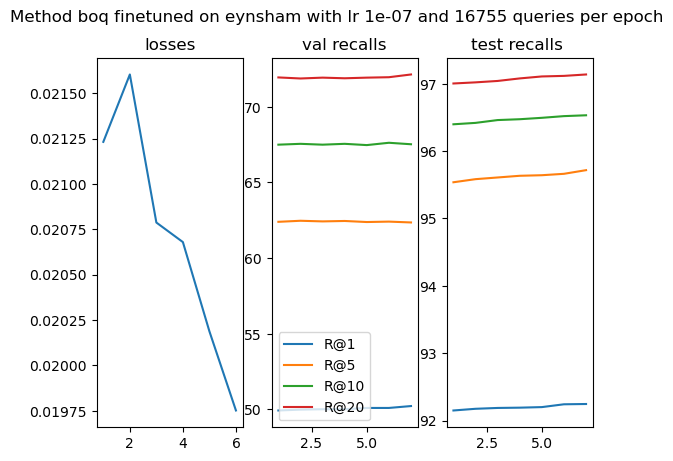

test recalls were [92.17463965 95.58387299 96.4194694  97.02109881] for the highest validation R@5
Original model results were [92.14957176 95.53791519 96.39857949 97.00438688] 
7
16755
average epoch took1:42:05.085884 and median: 1:42:54.916019
training backbone: original with model.eval
training aggregator: True
augmentations: True


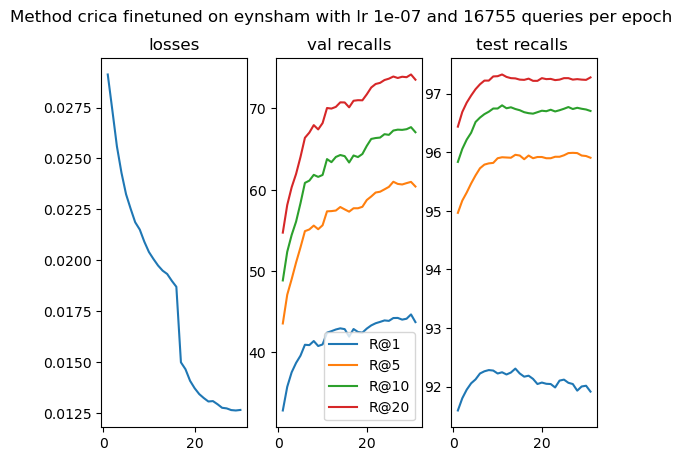

test recalls were [92.06601212 95.98495926 96.77041989 97.26342177] for the highest validation R@5
Original model results were [91.59390015 94.96553165 95.83455191 96.43618132] 
7
16755
average epoch took2:03:59.751074 and median: 2:03:55.191774
training backbone: original with model.eval
training aggregator: True
augmentations: True


In [67]:
train_datas=["gsv"]*8    
methods= ["boq", "crica"]*4
datasets=["nordland","nordland", "amstertime","amstertime","sped","sped","eynsham","eynsham"]
nums =   ["2",       "7",        "2",         "12",         "0",   "",    "2",      "2"]
    
for i, method in enumerate(methods): 
    train_data=train_datas[i]
    method=method
    dataset=datasets[i]
    lr=str(1e-7)
    num=nums[i]
    saved_path= f"logs/{train_data}_{method}/logfile{train_data}_{method}_finetuned_on_{dataset}_{lr}_{num}.pth"
    # saved_path= "logs/gsv_crica/logfilegsv_crica_finetuned_on_nordland.pth1e-05"
    logfile=torch.load(saved_path)
    args=logfile['args']

    # 0 -> R@1 1 R@5 2 R@10 3 R@20
    recall_value=1
    show_num=-1
    recalls=np.array(logfile["recalls"])[:show_num]
    recall_orig=np.array([recalls[0]]*len(recalls))[:show_num]
    losses=logfile['losses']
    avg_losses=[np.average(loss) for loss in losses][:show_num]

    fig,[ax1,ax2,ax3]=plt.subplots(1,3)

    plt.suptitle(f"Method {method} finetuned on {dataset} with lr {lr} and {args.queries_per_epoch} queries per epoch")
    ax1.set_title("losses")
    title=["Recall@1","Recall@5","Recall@10","Recall@20"]
    ax2.set_title('val recalls')
    ax3.set_title("test recalls ")
    # ax1.set_ylim([0,max(avg_losses)*1.2])
    ax1.plot(np.linspace(1,len(avg_losses),len(avg_losses)),avg_losses)

    ax2.plot(np.linspace(1,len(recalls),len(recalls)),recalls[:,0])
    ax2.plot(np.linspace(1,len(recalls),len(recalls)),recalls[:,1])
    ax2.plot(np.linspace(1,len(recalls),len(recalls)),recalls[:,2])
    ax2.plot(np.linspace(1,len(recalls),len(recalls)),recalls[:,3])
    ax2.legend(["R@1","R@5","R@10","R@20"])
    tests=np.array(logfile["test_set_recalls"][:show_num])
    ax3.plot(np.linspace(1,len(tests),len(tests)),tests)

    s=0
    max_R5_val=np.argmax(recalls[:,1])
    # for s in range(0,4):
    #     print(f"for recall {recall_values[s]} the highest val is {max(recalls[:,s]):.2f} the highest test was {max(tests[:,s]):.2f} and the test R when max val was {tests[np.argmax(recalls[:,s])][s]:.2f}")

    args=logfile['args']
    fig.show()
    plt.show()
    
    print(f"test recalls were {tests[max_R5_val]} for the highest validation R@5")
    print(f"Original model results were {tests[0]} ")
    print(args.gpu_id)
    print(args.queries_per_epoch)
    if "times_per_epoch" in logfile.keys():
        times=np.array(logfile["times_per_epoch"])
        print(f"average epoch took{times.mean()} and median: {np.median(times)}")
    if "train_backbone" in args:
        print(f"training backbone: {args.train_backbone}")
        print(f"training aggregator: {args.train_aggregator}")
        print(f"augmentations: {args.augments}")

In [226]:

def create_plot(method, dataset,lr=1e-7,num="",show_num=-1,dots=False,patience=None,print_shizzl=False):
    lr=str(lr)
    train_data='gsv'
    saved_path= f"../logs/{train_data}_{method}/logfile{train_data}_{method}_finetuned_on_{dataset}_{lr}_{num}.pth"
    # saved_path= "logs/gsv_crica/logfilegsv_crica_finetuned_on_nordland.pth1e-05"
    logfile=torch.load(saved_path)
    args=logfile['args']
    recall_value=1
    recalls=np.array(logfile["recalls"])[:show_num]
    recall_orig=np.array([recalls[0]]*len(recalls))[:show_num]
    losses=logfile['losses']
    avg_losses=[np.average(loss) for loss in losses][:show_num]

    fig,[ax1,ax2,ax3]=plt.subplots(1,3)

    plt.suptitle(f"Method {method} finetuned on {dataset} with lr {lr} and {args.queries_per_epoch} queries per epoch")
    ax1.set_title("losses")
    title=["Recall@1","Recall@5","Recall@10","Recall@20"]
    ax2.set_title('val recalls')
    ax3.set_title("test recalls ")
    # ax1.set_ylim([0,max(avg_losses)*1.2])
    ax1.plot(np.linspace(1,len(avg_losses),len(avg_losses)),avg_losses)

    ax2.plot(np.linspace(1,len(recalls),len(recalls)),recalls[:,0])
    ax2.plot(np.linspace(1,len(recalls),len(recalls)),recalls[:,1])
    ax2.plot(np.linspace(1,len(recalls),len(recalls)),recalls[:,2])
    ax2.plot(np.linspace(1,len(recalls),len(recalls)),recalls[:,3])
    ax2.legend(["R@1","R@5","R@10","R@20"])
    # ax2.plot(np.linspace(1,len(recalls),len(recalls)),recall_orig[:,0])
    # ax2.plot(np.linspace(1,len(recalls),len(recalls)),recall_orig[:,1])
    # ax2.plot(np.linspace(1,len(recalls),len(recalls)),recall_orig[:,2])
    # ax2.plot(np.linspace(1,len(recalls),len(recalls)),recall_orig[:,3])
    tests=np.array(logfile["test_set_recalls"][:show_num])
    # tests.insert(0,[91.2,96.2,97.5,98.5])

    # ax3.set_xticklabels([0,*logfile['best_epoch']])
    ax3.plot(np.linspace(1,len(tests),len(tests)),tests)

    # logfile["best_epoch"]
    r5_best=recalls[0][1]
    if print_shizzl:
        print(args)
        print("original patience was",args.patience)
    not_improved_num=0
    if patience !=None:    
        args.patience=patience
    early_stopping_val=9
    for i, recall_val in enumerate(recalls):


        r5_now= recall_val[1]
        if r5_now>r5_best:
            r5_best=r5_now
            early_stopping_val=i
            not_improved_num=0
        else:
            not_improved_num+=1

        if not_improved_num>(args.patience*np.ceil(args.queries_per_epoch/args.log_frequency)):
            print(not_improved_num)
            
            break
        elif (i==len(recalls)-1 and r5_now==r5_best):
            print("not stopped earlier")

#     print(early_stopping_val)
    
    
    if dots:
        ax3.scatter([early_stopping_val+1]*4,tests[early_stopping_val])
        ax2.scatter([early_stopping_val+1]*4,recalls[early_stopping_val])
    s=0
    max_R5_val=np.argmax(recalls[:,1])
    best_epoch=logfile["best_epoch"][-1]
    best_evaluation=np.argwhere(np.array(logfile["best_epoch"])==best_epoch)[0]
    if print_shizzl:
        print(f"test recalls were {tests[early_stopping_val]} for the highest validation R@5")
        print(f"Original model results were {tests[0]} ")
        print(f"validation recalls were {recalls[early_stopping_val,1]} for the highest validation R@5")
        print(f"Original model validation results were {recalls[0,1]} ")
        if not_improved_num>(args.patience*np.ceil(args.queries_per_epoch/args.log_frequency)):
            print(f"Early stopping applied from logging {i}, best model is taken at {early_stopping_val}, current logging num: {len(recalls)}")
        else:
            print(f"Early stopping not applied yet, best model is taken at {early_stopping_val}, current logging num: {len(recalls)}")
#         print(f"best epoch num: {best_epoch}, based on a patience of {args.patience}")

#         # # for s in range(0,4):
#         #     print(f"for recall {recall_values[s]} the highest val is {max(recalls[:,s]):.2f} the highest test was {max(tests[:,s]):.2f} and the test R when max val was {tests[np.argmax(recalls[:,s])][s]:.2f}")

#         print(args.lr)
#         print(args.early_stopping,early_stopping_val)
        if "times_per_loop" in logfile.keys():
            times=np.array(logfile["times_per_loop"])
            print(f"this run took {times.sum()} till {time.ctime(os.path.getmtime(saved_path))}")
#             print(f"average epoch took{times.mean()} and median: {np.median(times)}")
        
#             print(f"augmentations: {args.augments}")
#             print(f"amount of loggings: {len(recalls)}")
            
#         print(f"this logfile was created on {time.ctime(os.path.getctime(saved_path))}")
    return avg_losses

In [85]:

def create_plot_r5_patience(method, dataset,lr=1e-7,num="",show_num=-1,dots=False,recall_value=1,patience_max=None,print_shizzl=False):
    lr=str(lr)
    train_data='gsv'
    saved_path= f"../logs/{train_data}_{method}/logfile{train_data}_{method}_finetuned_on_{dataset}_{lr}_{num}.pth"
    # saved_path= "logs/gsv_crica/logfilegsv_crica_finetuned_on_nordland.pth1e-05"
    logfile=torch.load(saved_path)
    args=logfile['args']
    
    recalls=np.array(logfile["recalls"])[:show_num]
    recall_orig=np.array([recalls[0]]*len(recalls))[:show_num]
    losses=logfile['losses']
    avg_losses=[np.average(loss) for loss in losses][:show_num]

#     fig,[ax1,ax2,ax3]=plt.subplots(1,3)

#     plt.suptitle(f"Method {method} finetuned on {dataset} with lr {lr} and {args.queries_per_epoch} queries per epoch")
#     ax1.set_title("losses")
    titles=["Recall@1","Recall@5","Recall@10","Recall@20"]
#     ax2.set_title('val recalls')
#     ax3.set_title("test recalls ")
#     # ax1.set_ylim([0,max(avg_losses)*1.2])
#     ax1.plot(np.linspace(1,len(avg_losses),len(avg_losses)),avg_losses)

#     ax2.plot(np.linspace(1,len(recalls),len(recalls)),recalls[:,0])
#     ax2.plot(np.linspace(1,len(recalls),len(recalls)),recalls[:,1])
#     ax2.plot(np.linspace(1,len(recalls),len(recalls)),recalls[:,2])
#     ax2.plot(np.linspace(1,len(recalls),len(recalls)),recalls[:,3])
#     ax2.legend(["R@1","R@5","R@10","R@20"])
#     # ax2.plot(np.linspace(1,len(recalls),len(recalls)),recall_orig[:,0])
#     # ax2.plot(np.linspace(1,len(recalls),len(recalls)),recall_orig[:,1])
#     # ax2.plot(np.linspace(1,len(recalls),len(recalls)),recall_orig[:,2])
#     # ax2.plot(np.linspace(1,len(recalls),len(recalls)),recall_orig[:,3])
    tests=np.array(logfile["test_set_recalls"][:show_num])
#     # tests.insert(0,[91.2,96.2,97.5,98.5])

#     # ax3.set_xticklabels([0,*logfile['best_epoch']])
#     ax3.plot(np.linspace(1,len(tests),len(tests)),tests)

    # logfile["best_epoch"]
    r5_patience=[]
    
    for patience in range(0,patience_max):
        
        r5_best=recalls[0][1]
        not_improved_num=0
        early_stopping_val=0
        
        for i, recall_val in enumerate(recalls):

            r5_now= recall_val[1]
            if r5_now>r5_best:
                r5_best=r5_now
                early_stopping_val=i
                not_improved_num=0
            else:
                not_improved_num+=1

            if not_improved_num>(patience*np.ceil(args.queries_per_epoch/args.log_frequency)):

                break
            elif (i==len(recalls)-1 and r5_now==r5_best):
                continue
                    
#                 print("not stopped earlier")

#         print(early_stopping_val)
#         print(tests[1])
#         print(args.seed)
#         print(early_stopping_val)
#         print(tests)
        if early_stopping_val==-1:
            r5_patience.append(0)
        r5_patience.append(tests[early_stopping_val][recall_value])
    
    
#     plt.plot(range(0,patience_max),r5_patience)
#     plt.scatter(15,r5_patience[15],c='r')
#     plt.title(f"{titles[recall_value]} on dataset {dataset} with method {method}" )
#     plt.ylabel(f"{titles[recall_value]}")
#     plt.xlabel(f"patience value")
               
#     plt.show()
            
    return r5_patience

In [149]:
from matplotlib import rcParams, rcdefaults
rcParams.update({
    'font.size': 16,         # General font size
    'axes.titlesize': 18,    # Title font size
    'axes.labelsize': 16,    # Axis label font size
    'xtick.labelsize': 14,   # X-axis tick font size
    'ytick.labelsize': 14,   # Y-axis tick font size
    'legend.fontsize': 14,   # Legend font size
    'figure.titlesize': 20   # Figure title font size
})

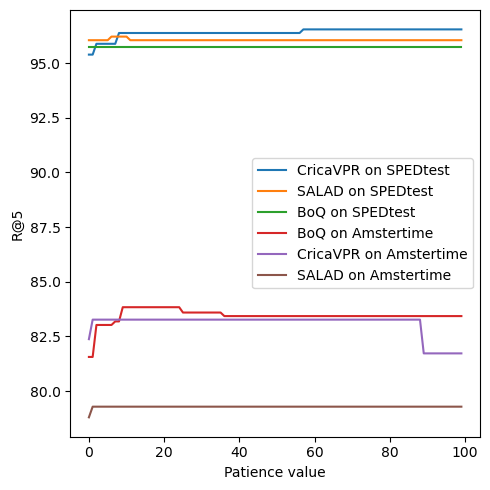

In [201]:
patience=100
show_num=-1
lr=1e-7
recall_value=1
dots=True
print_shizzl=True
titles=["R@1","R@5","R@10","R@20"]
# x=create_plot_r5_patience('boq','amstertime',lr=lr,num=1,show_num=show_num,dots=dots,patience_max=patience,print_shizzl=print_shizzl)
boq_ams=create_plot_r5_patience('boq','amstertime',lr=lr,num=1,show_num=show_num,dots=dots,patience_max=patience,print_shizzl=print_shizzl,recall_value=recall_value)
salad_ams=create_plot_r5_patience("salad",'amstertime',lr=1e-6,num=0,show_num=show_num,dots=dots,patience_max=patience,print_shizzl=print_shizzl,recall_value=recall_value)
crica_ams=create_plot_r5_patience('crica','amstertime',lr=1e-6,num=19,show_num=show_num,dots=dots,patience_max=patience,print_shizzl=print_shizzl,recall_value=recall_value)
boq_sped=create_plot_r5_patience('boq','sped',lr=lr,num=12,show_num=show_num,dots=True,patience_max=patience,print_shizzl=True,recall_value=recall_value)
salad_sped=create_plot_r5_patience("salad",'sped',lr=1e-6,num=0,show_num=show_num,dots=True,patience_max=patience,print_shizzl=True,recall_value=recall_value)
crica_sped=create_plot_r5_patience('crica','sped',lr=1e-6,num=1,show_num=show_num,dots=True,patience_max=patience,print_shizzl=True,recall_value=recall_value)

ams=np.array([boq_ams,salad_ams,crica_ams])
sped=np.array([boq_sped,salad_sped,crica_sped])
nord=np.array([create_plot_r5_patience('boq','nordland',lr=lr,num=0,show_num=show_num,dots=dots,patience_max=patience,print_shizzl=print_shizzl,recall_value=recall_value),
               create_plot_r5_patience('salad','nordland',lr=lr,num=0,show_num=show_num,dots=dots,patience_max=patience,print_shizzl=print_shizzl,recall_value=recall_value),
               create_plot_r5_patience('crica','nordland',lr=lr,num=16,show_num=show_num,dots=dots,patience_max=patience,print_shizzl=print_shizzl,recall_value=recall_value)])
eynsham=np.array([create_plot_r5_patience('boq','eynsham',lr=lr,num=1,show_num=show_num,dots=dots,patience_max=patience,print_shizzl=print_shizzl,recall_value=recall_value),
               create_plot_r5_patience('salad','eynsham',lr=lr,num=1,show_num=show_num,dots=dots,patience_max=patience,print_shizzl=print_shizzl,recall_value=recall_value),
               create_plot_r5_patience('crica','eynsham',lr=lr,num=8,show_num=show_num,dots=dots,patience_max=patience,print_shizzl=print_shizzl,recall_value=recall_value)])



# ax[0].set_title(f"{titles[recall_value]} on Amstertime and SPEDtest with different methods" )
if True:
    fig, ax=plt.subplots(1,1,figsize=[5,5])    
    ax.set_ylabel(f"{titles[recall_value]}")
    ax.set_xlabel(f"Patience value")
    # plt.show()
    # plt.plot([100,100],[95,100])
    ax.plot(sped[2].T)
    ax.plot(sped[1].T)
    ax.plot(sped[0].T)
    ax.plot(ams[0].T)
    ax.plot(ams[2].T)
    ax.plot(ams[1].T)
#     plt.plot([15,15],[78,98])
    ax.legend(labels=["CricaVPR on SPEDtest","SALAD on SPEDtest","BoQ on SPEDtest","BoQ on Amstertime","CricaVPR on Amstertime","SALAD on Amstertime"])
else:
    
    fig, ax=plt.subplots(1,1,figsize=[15,5])
    ax[0].set_ylabel(f"{titles[recall_value]}")
    ax[0].plot(ams.T)
    ax[0].set_xlabel(f"Patience value")
    # plt.show()
    # plt.plot([100,100],[95,100])
    ax[0].plot(sped.T)
    ax[0].legend(loc="upper left",bbox_to_anchor=(1, 0.5),labels=["BoQ on Amstertime","SALAD on Amstertime","CricaVPR on Amstertime","BoQ on SPEDtest","SALAD on SPEDtest","CricaVPR on SPEDtest"])

    # plt.show()
    plt.plot(nord.T[:6])

    # plt.show()
    plt.plot(eynsham.T[:6])
    ax[1].legend(loc="upper left",bbox_to_anchor=(1, 0.5),labels=["BoQ on Nordland","SALAD on Nordland","CricaVPR on Nordland","BoQ on Eynsham","SALAD on Eynsham","CricaVPR on Eynsham"])

    plt.ylabel(f"{titles[recall_value]}")

    plt.xlabel(f"Patience value")

plt.tight_layout()
plt.show()

original patience was 15
134
0
test recalls were [63.44435418 83.42810723 86.83996751 90.41429732] for the highest validation R@5
Original model results were [62.6320065  81.55970755 85.54021121 88.54589764] 
validation recalls were 93.4959349593496 for the highest validation R@5
Original model validation results were 88.07588075880759 
Early stopping not applied yet
original patience was 125
34
0
test recalls were [58.08285946 78.55402112 83.83428107 87.73354996] for the highest validation R@5
Original model results were [58.245329   78.79772543 83.67181154 87.81478473] 
validation recalls were 81.57181571815718 for the highest validation R@5
Original model validation results were 77.50677506775068 
Early stopping not applied yet
original patience was 125
261
0
test recalls were [64.50040617 83.18440292 87.00243704 90.9829407 ] for the highest validation R@5
Original model results were [64.25670187 82.37205524 87.16490658 91.30787977] 
validation recalls were 88.07588075880759 for the

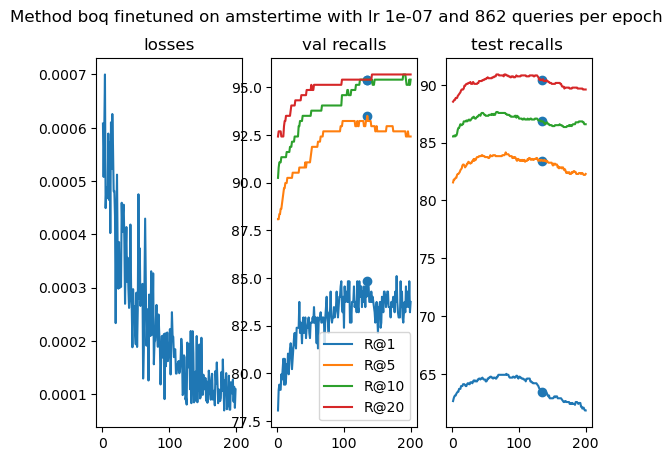

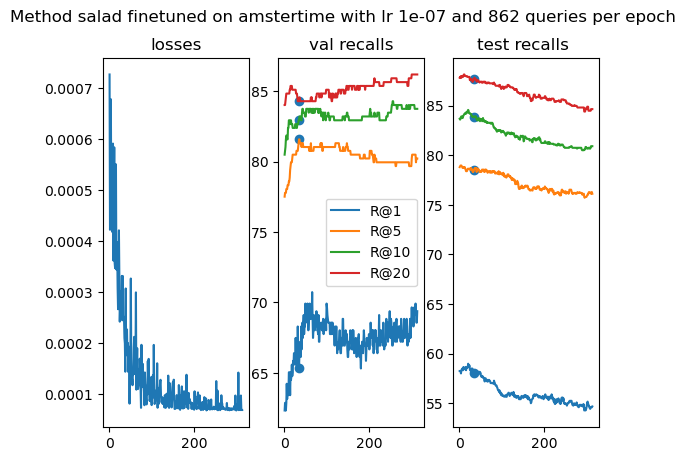

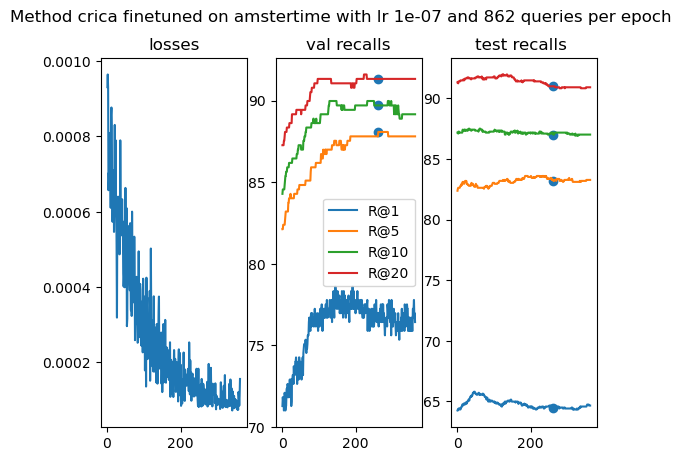

In [105]:
patience=1000
show_num=-1
lr=1e-7
dots=True
print_shizzl=True
loss1=create_plot('boq','amstertime',lr=lr,num=1,show_num=show_num,dots=dots,patience=patience,print_shizzl=print_shizzl)
loss1=create_plot("salad",'amstertime',lr=lr,num=7,show_num=show_num,dots=dots,patience=patience,print_shizzl=print_shizzl)
loss1=create_plot('crica','amstertime',lr=lr,num=23,show_num=show_num,dots=dots,patience=patience,print_shizzl=print_shizzl)


Namespace(datasets_folder='datasets_vg/datasets', dataset_name='amstertime', method='boq', num_workers=6, train_batch_size=16, seed=0, infer_batch_size=16, mining='full', lr=1e-07, margin=0.1, criterion='triplet', optim='adam', negs_num_per_query=2, epochs_num=200, resume='weights/gsv_boq.pth', queries_per_epoch=862, patience=15, test_method='hard_resize', augments=True, create_augments=False, use_val_augments=True, val_save_dir='/home/osverburg/validation', log_dir='logs', device='cuda', gpu_id='6', pca=False, pca_folder=None, val_positive_dist_threshold=25, train_positives_dist_threshold=10, backbone='DINOV2', registers=False, rerank_num=100, descriptors_dimension=12288, dense_feature_map_size=[61, 61, 128], recall_values=[1, 5, 10, 20], no_labels=False, resize=[322, 322], efficient_ram_testing=False, neg_samples_num=1000, is_trainref=True, ckpnt_path=None, train_backbone='original with model.eval', train_aggregator=True, image_size=[322, 322], features_dim=12288, triplets=False, cac

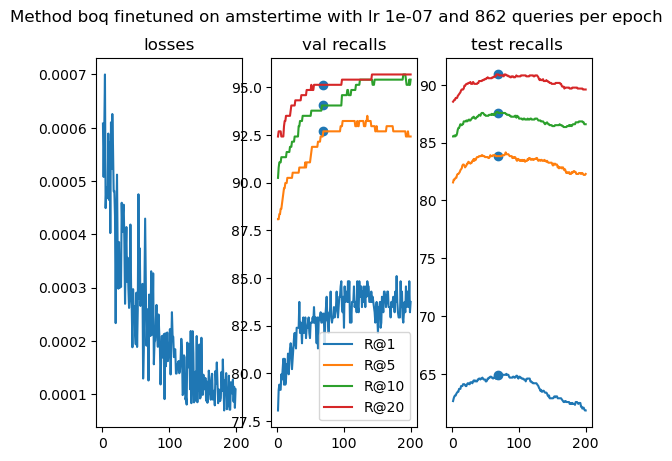

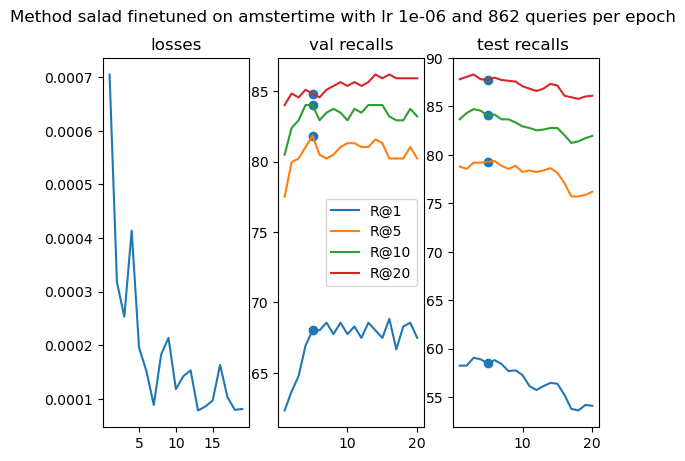

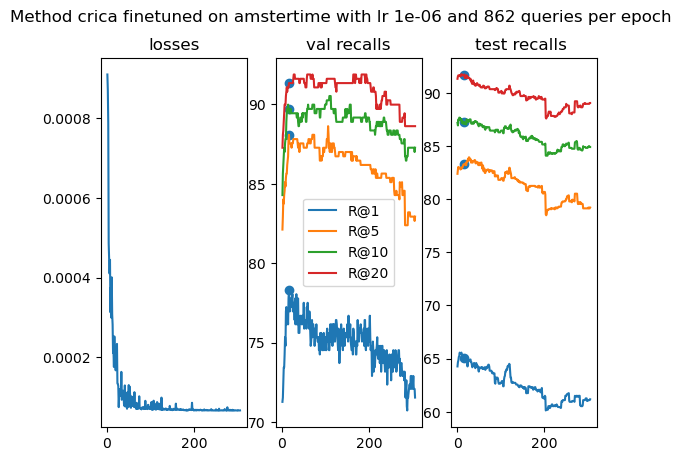

In [193]:
patience=15
show_num=-1
lr=1e-7
dots=True
print_shizzl=True
loss1=create_plot('boq','amstertime',lr=lr,num=1,show_num=show_num,dots=dots,patience=patience,print_shizzl=print_shizzl)
loss1=create_plot("salad",'amstertime',lr=1e-6,num=0,show_num=show_num,dots=dots,patience=patience,print_shizzl=print_shizzl)
loss1=create_plot('crica','amstertime',lr=1e-6,num=19,show_num=show_num,dots=dots,patience=patience,print_shizzl=print_shizzl)


original patience was 15
68
test recalls were [64.90658002 83.83428107 87.57108042 90.90170593] for the highest validation R@5
Original model results were [62.6320065  81.55970755 85.54021121 88.54589764] 
validation recalls were 92.6829268292683 for the highest validation R@5
Original model validation results were 88.07588075880759 
Early stopping applied from logging 84, best model is taken at 68
original patience was 15
34
test recalls were [58.08285946 78.55402112 83.83428107 87.73354996] for the highest validation R@5
Original model results were [58.245329   78.79772543 83.67181154 87.81478473] 
validation recalls were 81.57181571815718 for the highest validation R@5
Original model validation results were 77.50677506775068 
Early stopping applied from logging 50, best model is taken at 34
original patience was 15
22
test recalls were [64.90658002 83.18440292 87.32737612 91.63281885] for the highest validation R@5
Original model results were [64.25670187 82.37205524 87.16490658 91.

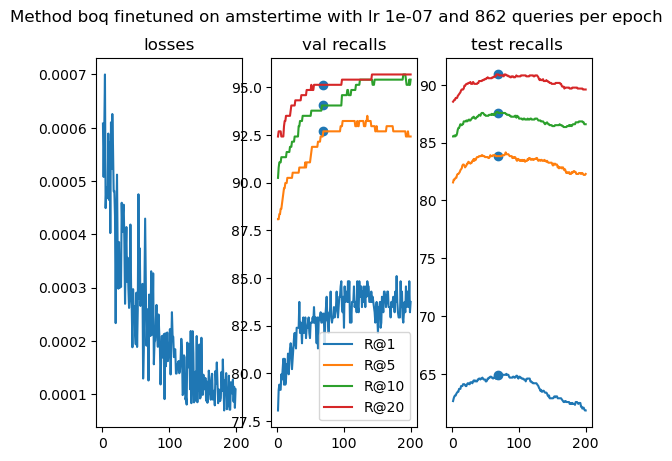

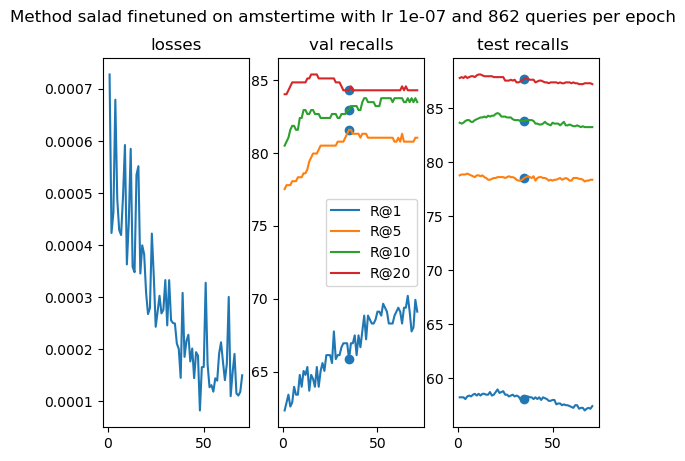

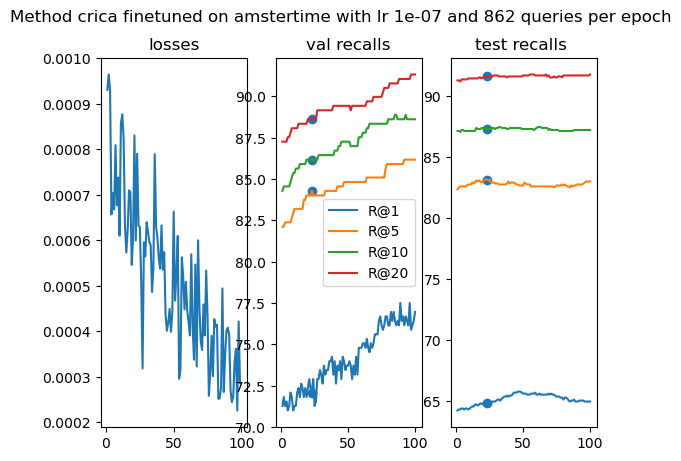

In [88]:
patience=None
show_num=-1
lr=1e-7
dots=True
print_shizzl=True
loss1=create_plot('boq','amstertime',lr=lr,num=1,show_num=show_num,dots=dots,patience=patience,print_shizzl=print_shizzl)
loss1=create_plot("salad",'amstertime',lr=lr,num=5,show_num=show_num,dots=dots,patience=patience,print_shizzl=print_shizzl)
loss1=create_plot('crica','amstertime',lr=lr,num=21,show_num=show_num,dots=dots,patience=patience,print_shizzl=print_shizzl)


Namespace(datasets_folder='datasets_vg/datasets', dataset_name='nordland', method='boq', num_workers=6, train_batch_size=16, seed=0, infer_batch_size=16, mining='full', lr=1e-07, margin=0.1, criterion='triplet', optim='adam', negs_num_per_query=2, epochs_num=100, log_frequency=1008, resume='weights/gsv_boq.pth', queries_per_epoch=19315, patience=5, test_method='hard_resize', augments=True, create_augments=False, use_val_augments=True, val_save_dir='/home/osverburg/validation', log_dir='logs', device='cuda', gpu_id='6', pca=False, pca_folder=None, val_positive_dist_threshold=25, train_positives_dist_threshold=10, backbone='DINOV2', descriptors_dimension=12288, recall_values=[1, 5, 10, 20], no_labels=False, resize=[322, 322], efficient_ram_testing=False, neg_samples_num=1000, ckpnt_path=None, is_trainref=True, is_best=False, image_size=[322, 322], features_dim=12288, triplets=False, cache_refresh_rate=19315, early_stopping=False, early_stopping_epoch=6, save_dir='logs/gsv_boq')
original 

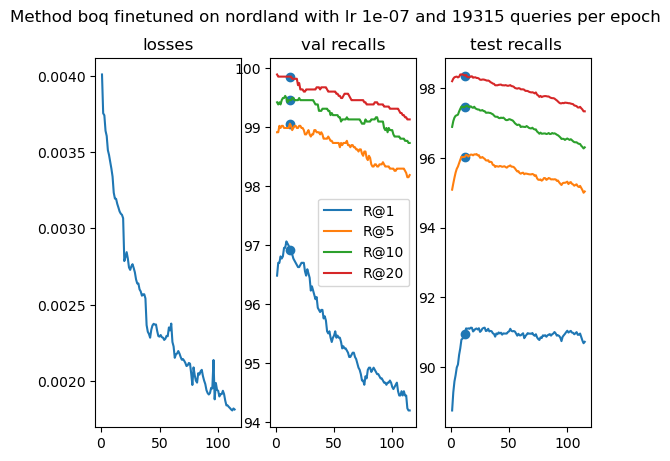

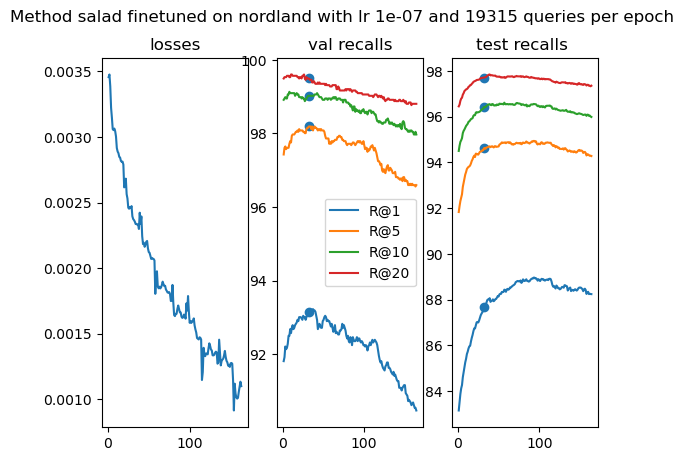

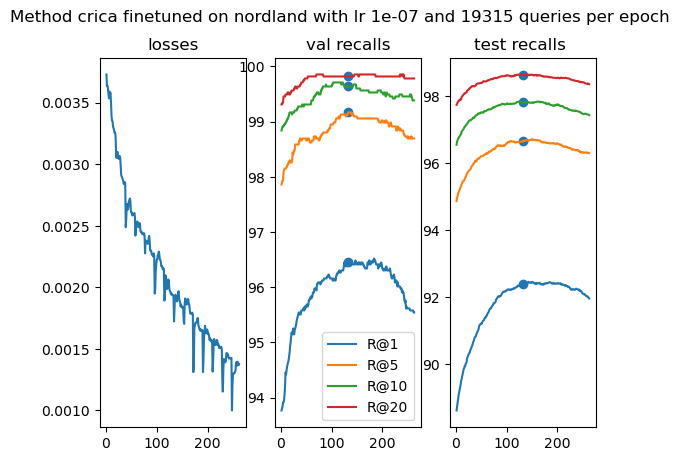

In [91]:
show_num=-1
loss1=create_plot('boq','nordland',lr=lr,num=0,show_num=show_num,dots=True,patience=patience,print_shizzl=True)
loss1=create_plot("salad",'nordland',lr=lr,num=0,show_num=show_num,dots=True,patience=patience,print_shizzl=True)
loss1=create_plot('crica','nordland',lr=lr,num=16,show_num=show_num,dots=True,patience=patience,print_shizzl=True)


Namespace(datasets_folder='datasets_vg/datasets', dataset_name='sped', method='boq', num_workers=6, train_batch_size=16, seed=0, infer_batch_size=16, mining='full', lr=1e-07, margin=0.1, criterion='triplet', optim='adam', negs_num_per_query=2, epochs_num=200, resume='weights/gsv_boq.pth', queries_per_epoch=425, patience=15, test_method='hard_resize', augments=True, create_augments=False, use_val_augments=True, val_save_dir='/home/osverburg/validation', log_dir='logs', device='cuda', gpu_id='6', pca=False, pca_folder=None, val_positive_dist_threshold=25, train_positives_dist_threshold=10, backbone='DINOV2', registers=False, rerank_num=100, descriptors_dimension=12288, dense_feature_map_size=[61, 61, 128], recall_values=[1, 5, 10, 20], no_labels=False, resize=[322, 322], efficient_ram_testing=False, neg_samples_num=1000, is_trainref=True, ckpnt_path=None, image_size=[322, 322], features_dim=12288, triplets=False, cache_refresh_rate=425, log_frequency=425, early_stopping=True, early_stopp

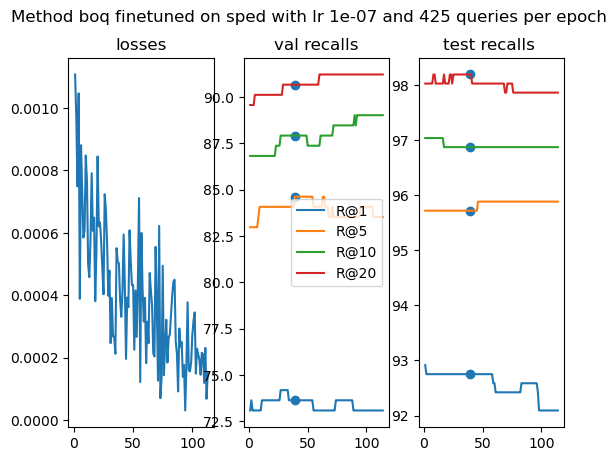

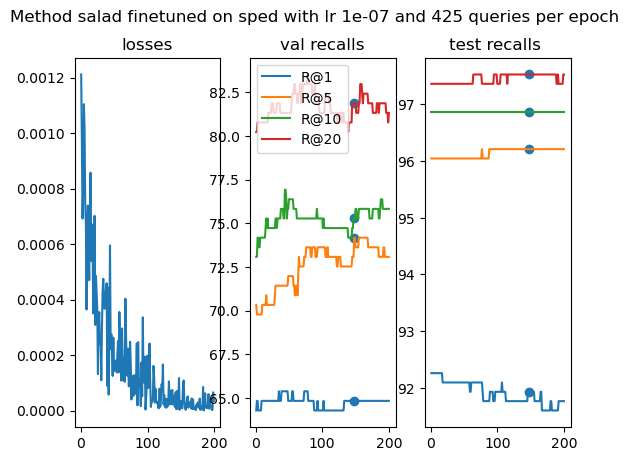

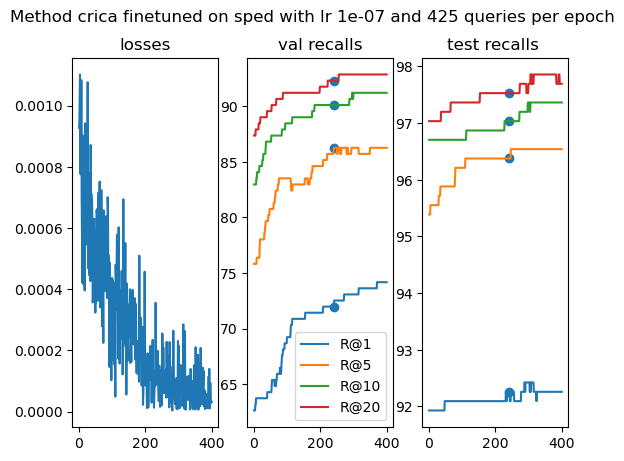

In [25]:
show_num=-1
patience=100
loss1=create_plot('boq','sped',lr=lr,num=12,show_num=show_num,dots=True,patience=patience,print_shizzl=True)
loss1=create_plot("salad",'sped',lr=lr,num=6,show_num=show_num,dots=True,patience=patience,print_shizzl=True)
loss1=create_plot('crica','sped',lr=lr,num=4,show_num=show_num,dots=True,patience=patience,print_shizzl=True)
# loss1=create_plot('crica','sped',lr=lr,num=4,show_num=show_num,dots=True,patience=patience,print_shizzl=True)


original patience was 15
8
test recalls were [92.75123558 95.71663921 97.03459638 98.1878089 ] for the highest validation R@5
Original model results were [92.91598023 95.71663921 97.03459638 98.02306425] 
validation recalls were 84.06593406593407 for the highest validation R@5
Original model validation results were 82.96703296703298 
Early stopping applied from logging 24, best model is taken at 8
original patience was 15
29
test recalls were [92.092257   96.0461285  96.86985173 97.36408567] for the highest validation R@5
Original model results were [92.25700165 96.0461285  96.86985173 97.36408567] 
validation recalls were 71.42857142857143 for the highest validation R@5
Original model validation results were 70.32967032967034 
Early stopping applied from logging 45, best model is taken at 29
original patience was 15
75
test recalls were [92.092257   95.88138386 96.70510708 97.36408567] for the highest validation R@5
Original model results were [91.92751236 95.38714992 96.70510708 97.0

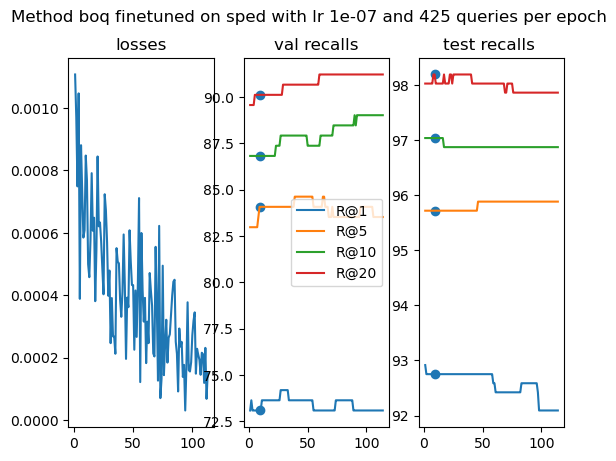

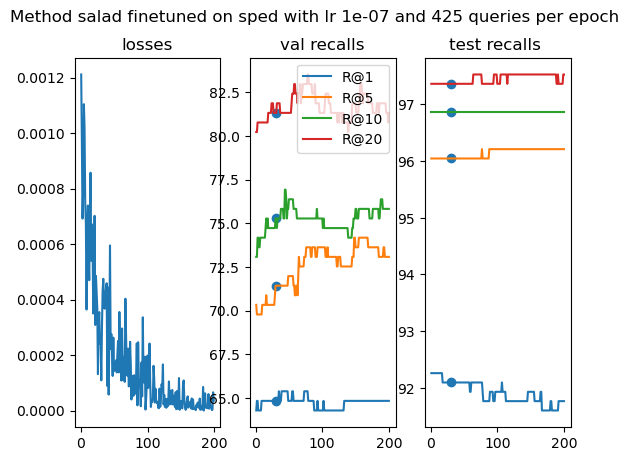

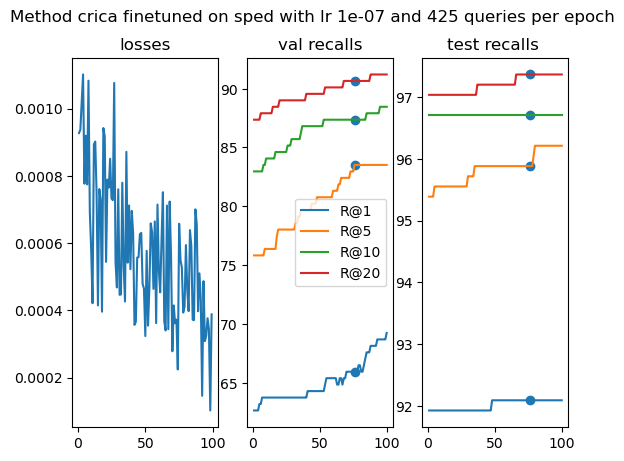

In [90]:
show_num=-1
patience=None
loss1=create_plot('boq','sped',lr=lr,num=12,show_num=show_num,dots=True,patience=patience,print_shizzl=True)
loss1=create_plot("salad",'sped',lr=lr,num=6,show_num=show_num,dots=True,patience=patience,print_shizzl=True)
loss1=create_plot('crica','sped',lr=lr,num=3,show_num=show_num,dots=True,patience=patience,print_shizzl=True)
# loss1=create_plot('crica','sped',lr=lr,num=4,show_num=show_num,dots=True,patience=patience,print_shizzl=True)


13
test recalls were [92.21224149 95.82201797 96.63254648 97.1631502 ] for the highest validation R@5
Original model results were [92.14957176 95.53791519 96.39857949 97.00438688] 
validation recalls were 62.82729805013928 for the highest validation R@5
Original model validation results were 62.66016713091922 
Early stopping not applied yet
18
test recalls were [92.08272404 95.61311886 96.50720702 97.12972634] for the highest validation R@5
Original model results were [91.49362858 95.02820138 95.92228953 96.59494464] 
validation recalls were 48.1058495821727 for the highest validation R@5
Original model validation results were 45.79387186629526 
Early stopping not applied yet
63
test recalls were [91.97409651 95.4877794  96.42364738 96.98767495] for the highest validation R@5
Original model results were [91.59390015 94.96553165 95.83455191 96.43618132] 
validation recalls were 58.37047353760446 for the highest validation R@5
Original model validation results were 54.52646239554318 
Ear

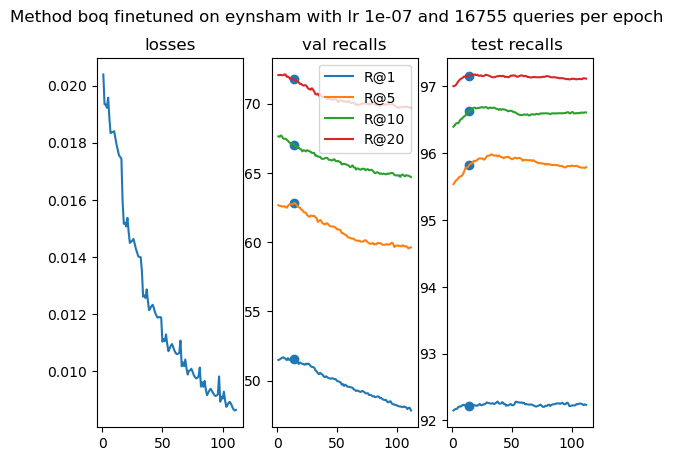

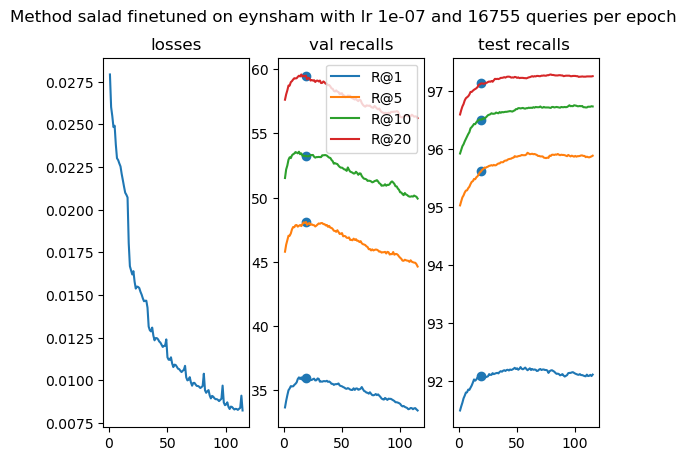

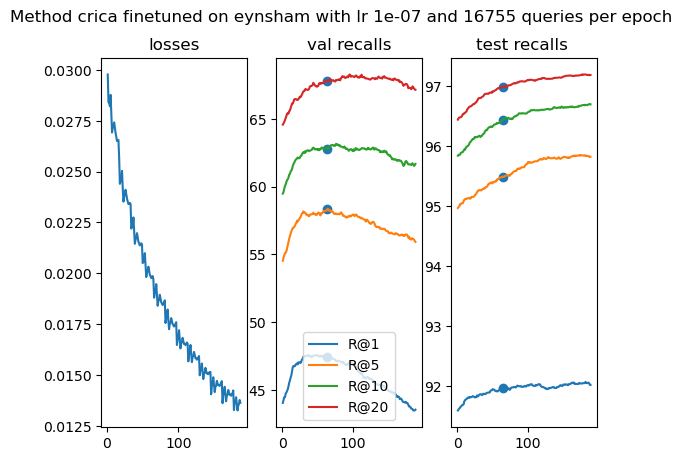

In [75]:
show_num=-1
loss1=create_plot('boq','eynsham',lr=lr,num=1,show_num=show_num,dots=True,patience=patience,print_shizzl=True)
loss1=create_plot("salad",'eynsham',lr=lr,num=1,show_num=show_num,dots=True,patience=patience,print_shizzl=True)
loss1=create_plot('crica','eynsham',lr=lr,num=8,show_num=show_num,dots=True,patience=patience,print_shizzl=True)


original patience was 15
34
test recalls were [58.08285946 78.55402112 83.83428107 87.73354996] for the highest validation R@5
Original model results were [58.245329   78.79772543 83.67181154 87.81478473] 
validation recalls were 81.57181571815718 for the highest validation R@5
Original model validation results were 77.50677506775068 
Early stopping applied from logging 50, best model is taken at 34
original patience was 125
199
test recalls were [57.43298132 77.74167344 83.42810723 87.65231519] for the highest validation R@5
Original model results were [58.245329   78.79772543 83.67181154 87.81478473] 
validation recalls were 87.26287262872629 for the highest validation R@5
Original model validation results were 79.94579945799458 
Early stopping applied from logging 325, best model is taken at 199
original patience was 20
51
test recalls were [58.89520715 78.96019496 83.99675061 88.22095857] for the highest validation R@5
Original model results were [58.245329   78.79772543 83.6718115

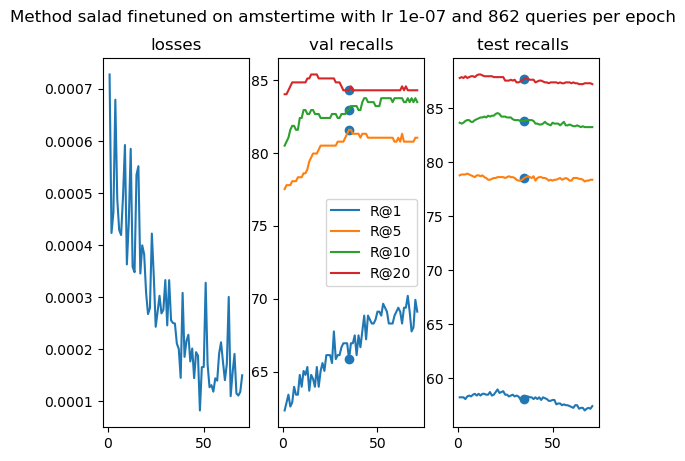

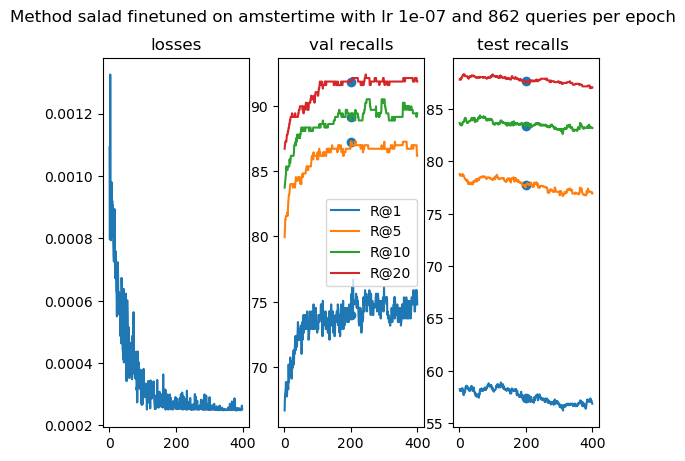

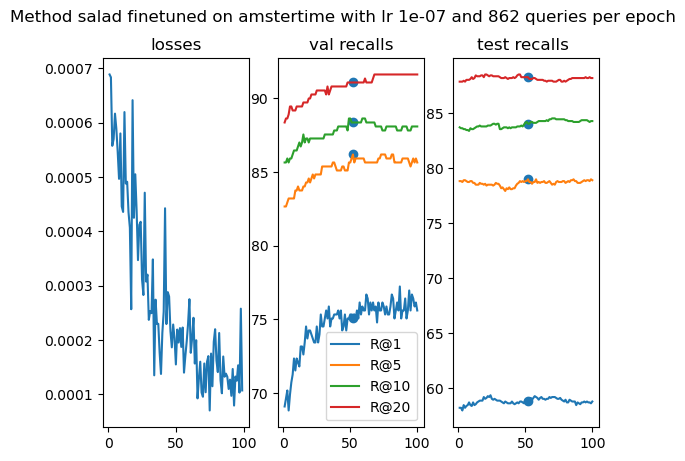

In [92]:
patience=None
loss1=create_plot('salad','amstertime',lr=lr,num=5,show_num=show_num,dots=True,patience=patience,print_shizzl=True)
loss1=create_plot('salad','amstertime',lr=lr,num=6,show_num=show_num,dots=True,patience=patience,print_shizzl=True)
loss1=create_plot("salad",'amstertime',lr=lr,num=1,show_num=show_num,dots=True,patience=patience,print_shizzl=True)


Namespace(datasets_folder='../datasets_vg/datasets', dataset_name='nordland', method='salad', original_training_data='gsv', num_workers=6, train_batch_size=16, seed=0, infer_batch_size=16, mining='full', lr=1e-07, margin=0.1, criterion='triplet', optim='adam', negs_num_per_query=2, epochs_num=100, log_frequency=1008, ablation=False, ablation_nordland=True, save_models=False, scheduled_lr=False, gamma_lr=0.5, step_lr=10, test_val_queries=0.1, grayscale=False, exact_match=False, resume='', queries_per_epoch=19315, patience=5, test_method='hard_resize', augments=True, create_augments=False, use_val_augments=True, val_save_dir='/home/osverburg/validation', log_dir='../logs', device='cuda', gpu_id='7', pca=False, pca_folder=None, random_vals=True, stop_after_patience=False, val_split=0.3, val_positive_dist_threshold=25, train_positives_dist_threshold=10, backbone=None, descriptors_dimension=8448, recall_values=[1, 5, 10, 20], no_labels=False, resize=[322, 322], efficient_ram_testing=False, 

RuntimeError: PytorchStreamReader failed reading zip archive: failed finding central directory

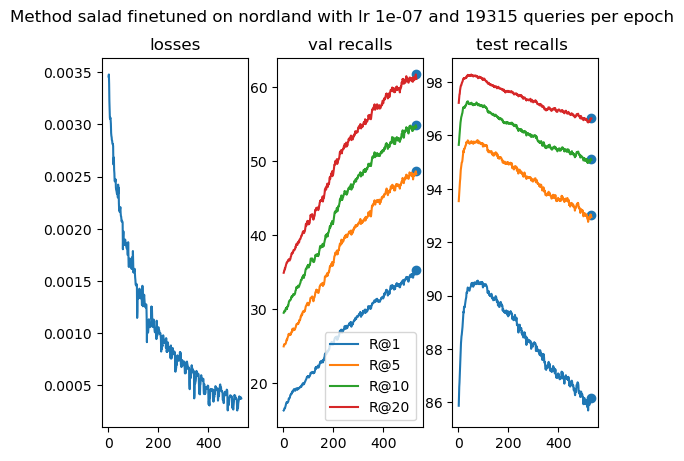

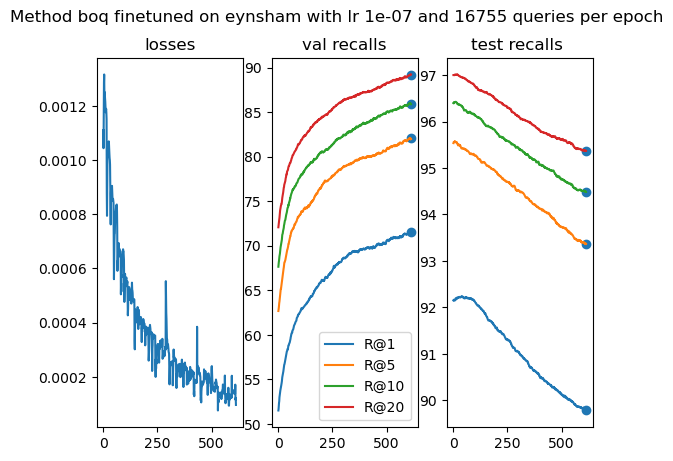

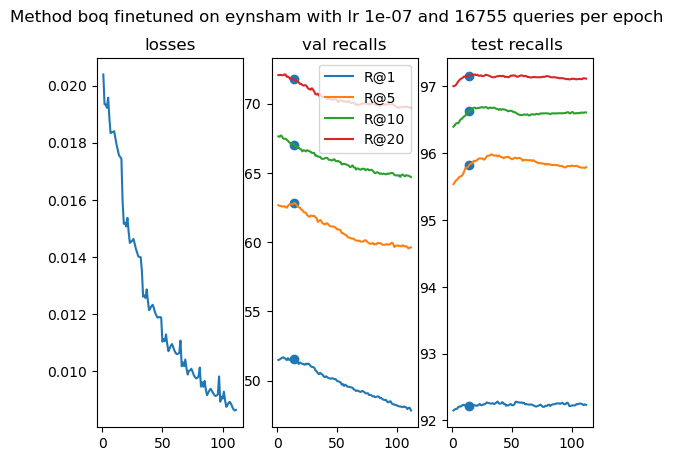

In [34]:
show_num=-1
lr=1e-7
patience=None
print_shizzl=True
# loss1=create_plot("crica",'nordland',lr=1e-6,num=7,show_num=show_num,dots=True,patience=patience,print_shizzl=True)
# loss1=create_plot("boq",'nordland',lr=1e-7,num=5,show_num=show_num,dots=True,patience=patience,print_shizzl=True)
# loss1=create_plot("boq",'nordland',lr=1e-7,num=0,show_num=show_num,dots=True,patience=patience,print_shizzl=True)
# loss1=create_plot("crica",'amstertime',lr=1e-8,num=3,show_num=show_num,dots=True,patience=patience,print_shizzl=True)
# loss1=create_plot("salad",'amstertime',lr=1e-8,num="",show_num=show_num,dots=True,patience=patience,print_shizzl=True)
loss1=create_plot("salad",'nordland',lr=1e-7,num="1",show_num=show_num,dots=True,patience=patience,print_shizzl=True)
# # loss1=create_plot("boq",'eynsham',lr=lr,num=5,show_num=show_num,dots=True,patience=patience,print_shizzl=print_shizzl)
# loss1=create_plot("boq",'eynsham',lr=lr,num=6,show_num=show_num,dots=True,patience=patience,print_shizzl=print_shizzl)
# loss1=create_plot("boq",'eynsham',lr=lr,num=8,show_num=show_num,dots=True,patience=patience,print_shizzl=print_shizzl)
loss1=create_plot("boq",'eynsham',lr=lr,num=10,show_num=show_num,dots=True,patience=patience,print_shizzl=print_shizzl)
loss1=create_plot("boq",'eynsham',lr=lr,num=1,show_num=show_num,dots=True,patience=patience,print_shizzl=print_shizzl)
loss1=create_plot("boq",'tokyo247',lr=lr,num="",show_num=show_num,dots=True,patience=patience,print_shizzl=print_shizzl)
# loss1=create_plot("crica",'eynsham',lr=1e-6,num=16,show_num=show_num,dots=True,patience=None,print_shizzl=print_shizzl)
# loss1=create_plot("crica",'amstertime',lr=1e-8,num=3,show_num=show_num,dots=True,patience=None,print_shizzl=print_shizzl)


Namespace(datasets_folder='../datasets_vg/datasets', dataset_name='nordland', method='crica', original_training_data='gsv', num_workers=6, train_batch_size=16, seed=0, infer_batch_size=16, mining='full', lr=1e-06, margin=0.1, criterion='triplet', optim='adam', negs_num_per_query=2, epochs_num=100, log_frequency=1008, ablation=False, ablation_nordland=True, save_models=True, test_val_queries=0.1, grayscale=False, exact_match=False, resume='', queries_per_epoch=19315, patience=5, test_method='hard_resize', augments=True, create_augments=False, use_val_augments=True, val_save_dir='/home/osverburg/validation', log_dir='../logs', device='cuda', gpu_id='6', pca=False, pca_folder=None, random_vals=True, stop_after_patience=False, val_split=0.3, val_positive_dist_threshold=25, train_positives_dist_threshold=10, backbone=None, descriptors_dimension=10752, recall_values=[1, 5, 10, 20], no_labels=False, resize=[224, 224], efficient_ram_testing=False, neg_samples_num=1000, ckpnt_path=None, is_trai

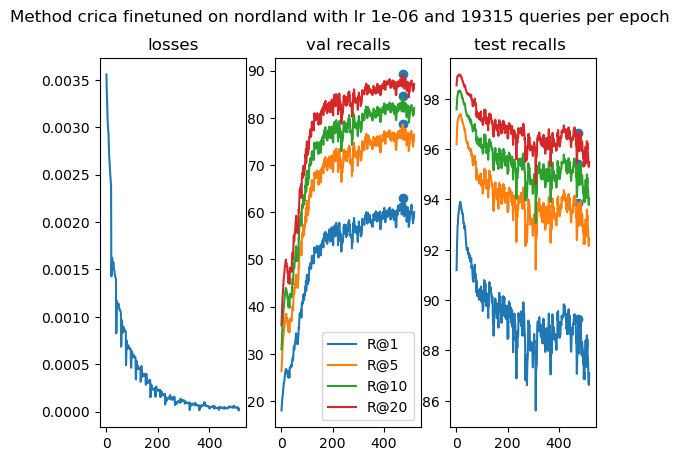

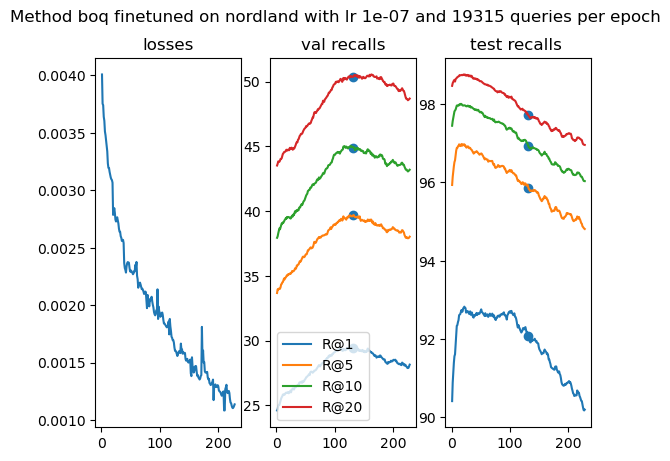

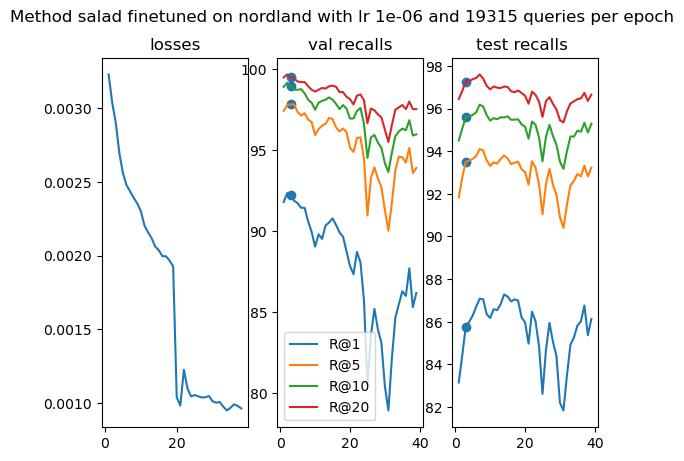

In [181]:
loss1=create_plot("crica",'nordland',lr=1e-6,num="7",show_num=show_num,dots=True,patience=None,print_shizzl=print_shizzl)
loss1=create_plot("boq",'nordland',lr=1e-7,num="5",show_num=show_num,dots=True,patience=None,print_shizzl=print_shizzl)
loss1=create_plot("salad",'nordland',lr=1e-6,num="",show_num=show_num,dots=True,patience=None,print_shizzl=print_shizzl)


Namespace(datasets_folder='../datasets_vg/datasets', dataset_name='nordland', method='salad', original_training_data='gsv', num_workers=6, train_batch_size=16, seed=0, infer_batch_size=16, mining='full', lr=1e-06, margin=0.1, criterion='triplet', optim='adam', negs_num_per_query=2, epochs_num=400, log_frequency=1008, ablation=False, ablation_nordland=False, save_models=True, scheduled_lr=False, gamma_lr=0.5, step_lr=10, test_val_queries=0.1, grayscale=False, exact_match=False, resume='', queries_per_epoch=19315, patience=2, test_method='hard_resize', augments=True, create_augments=False, use_val_augments=True, val_save_dir='/home/osverburg/validation', log_dir='../logs', device='cuda', gpu_id='5', pca=False, pca_folder=None, random_vals=True, stop_after_patience=True, val_split=0.3, val_positive_dist_threshold=25, train_positives_dist_threshold=10, backbone=None, descriptors_dimension=8448, recall_values=[1, 5, 10, 20], no_labels=False, resize=[322, 322], efficient_ram_testing=False, n

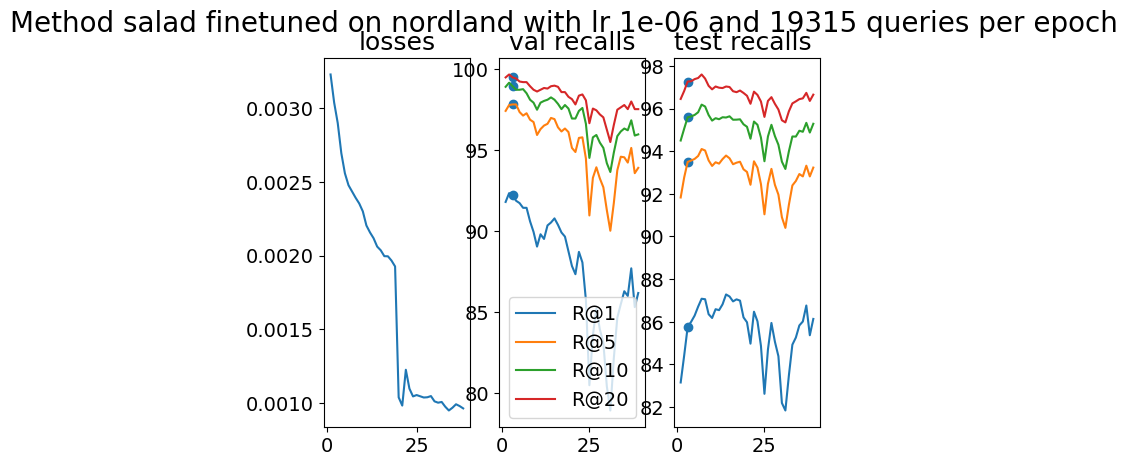

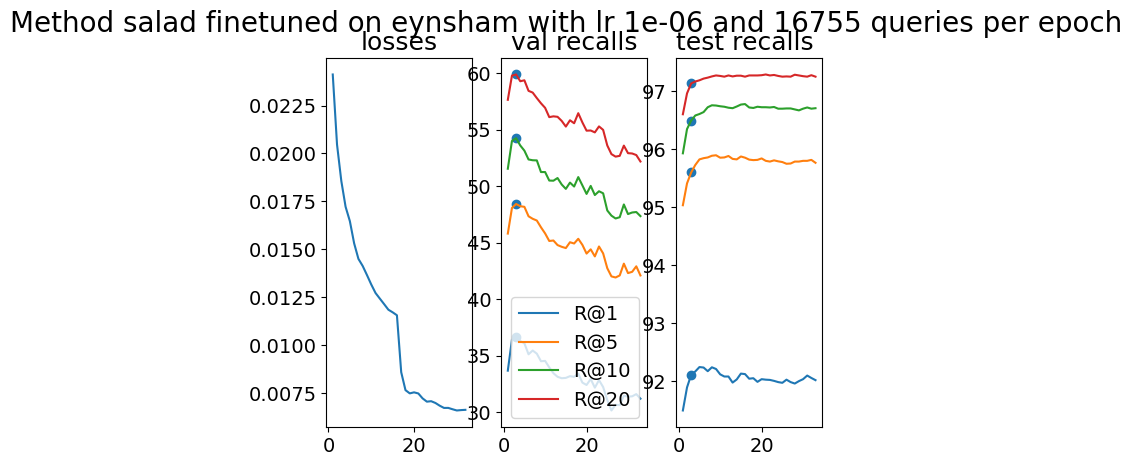

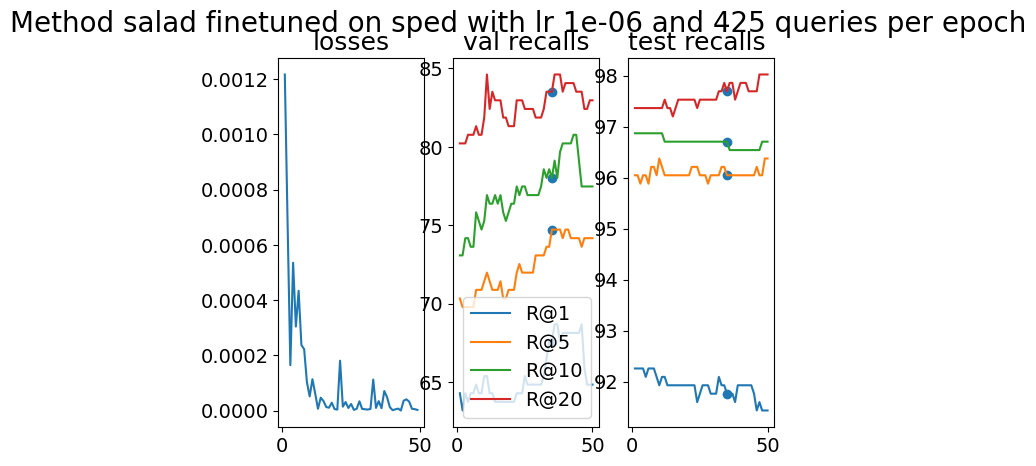

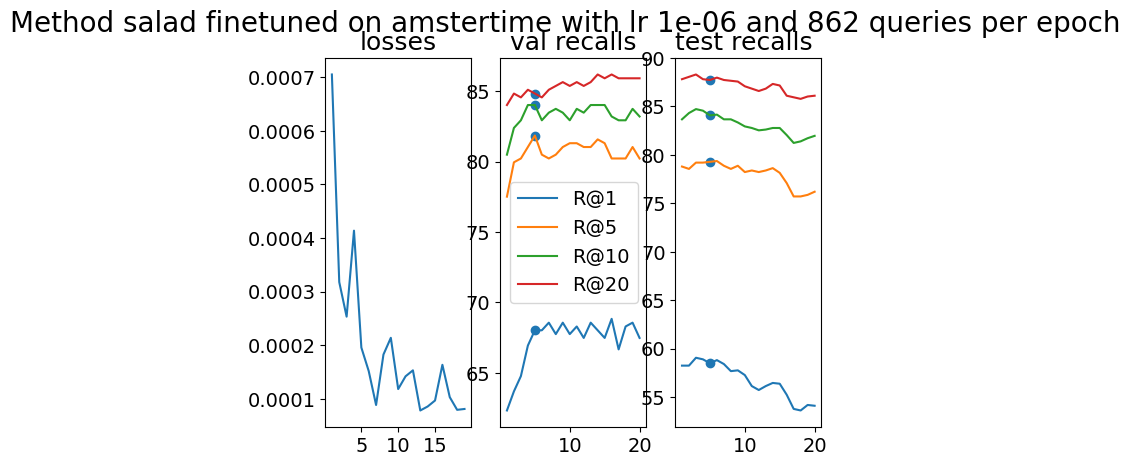

In [148]:

loss1=create_plot("salad",'nordland',lr=1e-6,num="",show_num=show_num,dots=True,patience=patience,print_shizzl=print_shizzl)

loss1=create_plot("salad",'eynsham',lr=1e-6,num="",show_num=show_num,dots=True,patience=patience,print_shizzl=print_shizzl)

loss1=create_plot("salad",'sped',lr=1e-6,num=0,show_num=show_num,dots=True,patience=patience,print_shizzl=print_shizzl)

loss1=create_plot("salad",'amstertime',lr=1e-6,num=0,show_num=show_num,dots=True,patience=patience,print_shizzl=print_shizzl)


Namespace(datasets_folder='../datasets_vg/datasets', dataset_name='nordland', method='crica', original_training_data='gsv', num_workers=6, train_batch_size=16, seed=0, infer_batch_size=16, mining='full', lr=1e-06, margin=0.1, criterion='triplet', optim='adam', negs_num_per_query=2, epochs_num=400, log_frequency=1008, ablation=False, ablation_nordland=False, save_models=True, scheduled_lr=False, gamma_lr=0.5, step_lr=10, test_val_queries=0.1, grayscale=False, exact_match=False, resume='', queries_per_epoch=19315, patience=2, test_method='hard_resize', augments=True, create_augments=False, use_val_augments=True, val_save_dir='/home/osverburg/validation', log_dir='../logs', device='cuda', gpu_id='5', pca=False, pca_folder=None, random_vals=True, stop_after_patience=True, val_split=0.3, val_positive_dist_threshold=25, train_positives_dist_threshold=10, backbone=None, descriptors_dimension=10752, recall_values=[1, 5, 10, 20], no_labels=False, resize=[224, 224], efficient_ram_testing=False, 

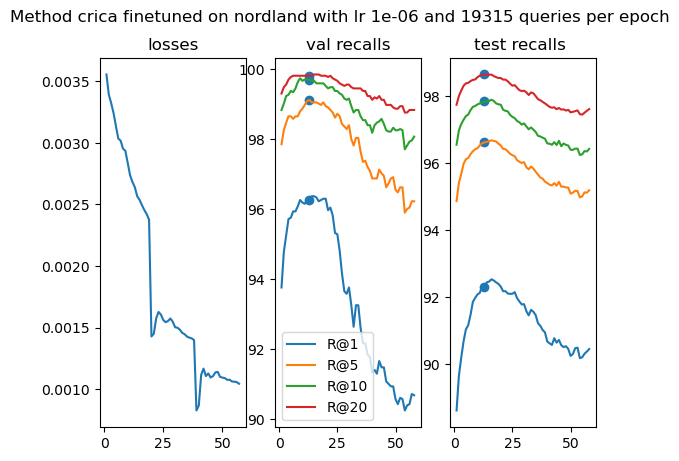

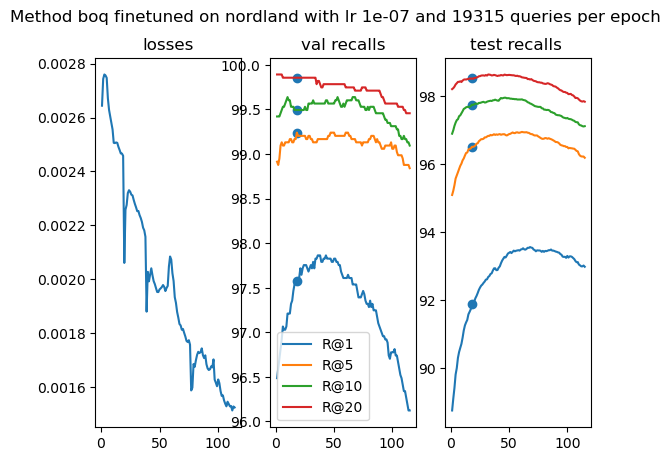

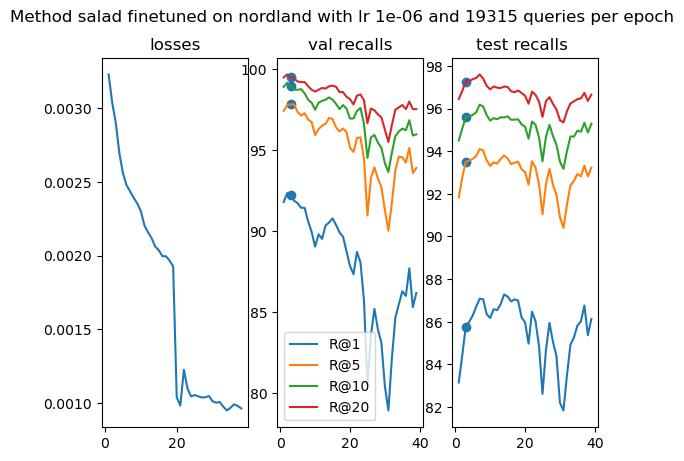

In [185]:
loss1=create_plot("crica",'nordland',lr=1e-6,num="8",show_num=show_num,dots=True,patience=None,print_shizzl=print_shizzl)
loss1=create_plot("boq",'nordland',lr=1e-7,num="7",show_num=show_num,dots=True,patience=None,print_shizzl=print_shizzl)
loss1=create_plot("salad",'nordland',lr=1e-6,num="",show_num=show_num,dots=True,patience=None,print_shizzl=print_shizzl)


Namespace(datasets_folder='../datasets_vg/datasets', dataset_name='eynsham', method='boq', original_training_data='gsv', num_workers=6, train_batch_size=16, seed=0, infer_batch_size=16, mining='full', lr=1e-07, margin=0.1, criterion='triplet', optim='adam', negs_num_per_query=2, epochs_num=100, log_frequency=1008, ablation=False, ablation_nordland=False, save_models=False, scheduled_lr=False, gamma_lr=0.5, step_lr=10, test_val_queries=0.1, grayscale=False, exact_match=False, resume='', queries_per_epoch=16755, patience=2, test_method='hard_resize', augments=True, create_augments=False, use_val_augments=True, val_save_dir='/home/osverburg/validation', log_dir='../logs', device='cuda', gpu_id='6', pca=False, pca_folder=None, random_vals=False, stop_after_patience=False, val_split=0.3, val_positive_dist_threshold=25, train_positives_dist_threshold=25, backbone='DINOV2', descriptors_dimension=12288, recall_values=[1, 5, 10, 20], no_labels=False, resize=[322, 322], efficient_ram_testing=Fal

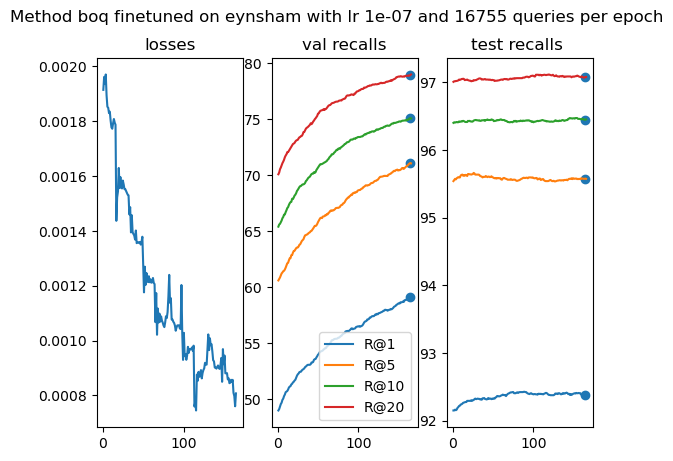

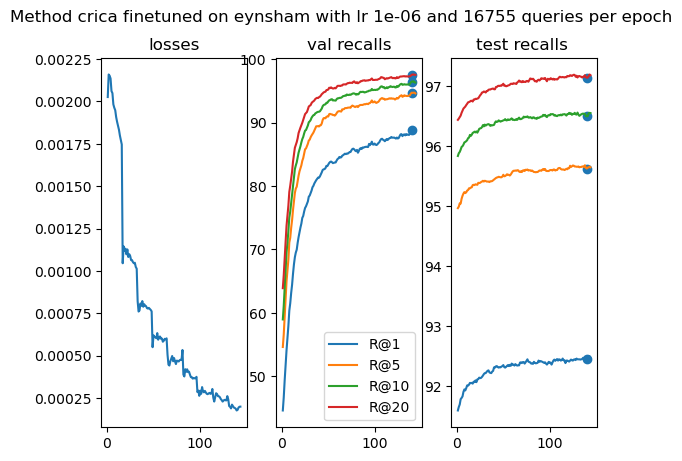

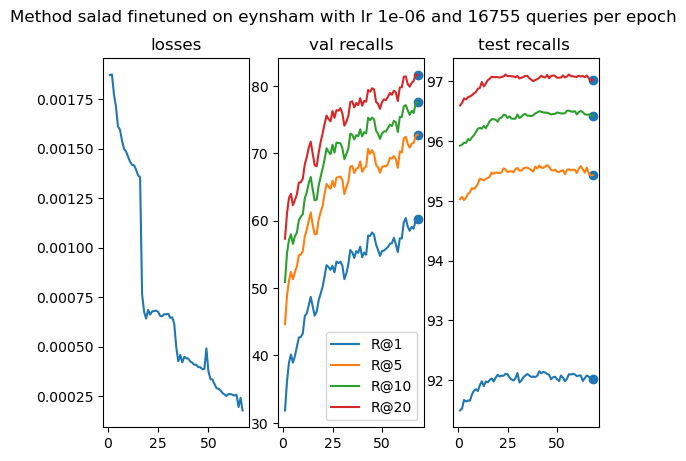

In [209]:
loss1=create_plot("boq",'eynsham',lr=lr,num=11,show_num=show_num,dots=True,patience=patience,print_shizzl=print_shizzl)
loss1=create_plot("crica",'eynsham',lr=1e-6,num="0",show_num=show_num,dots=True,patience=patience,print_shizzl=print_shizzl)
loss1=create_plot("salad",'eynsham',lr=1e-6,num="0",show_num=show_num,dots=True,patience=patience,print_shizzl=print_shizzl)


Namespace(datasets_folder='../datasets_vg/datasets', dataset_name='eynsham', method='boq', original_training_data='gsv', num_workers=6, train_batch_size=16, seed=0, infer_batch_size=16, mining='full', lr=1e-07, margin=0.1, criterion='triplet', optim='adam', negs_num_per_query=2, epochs_num=100, log_frequency=1008, ablation=False, ablation_nordland=False, save_models=False, scheduled_lr=False, gamma_lr=0.5, step_lr=10, test_val_queries=0.1, grayscale=False, exact_match=True, resume='', queries_per_epoch=16755, patience=5, test_method='hard_resize', augments=True, create_augments=False, use_val_augments=True, val_save_dir='/home/osverburg/validation', log_dir='../logs', device='cuda', gpu_id='6', pca=False, pca_folder=None, random_vals=True, stop_after_patience=False, val_split=0.3, val_positive_dist_threshold=25, train_positives_dist_threshold=10, backbone='DINOV2', descriptors_dimension=12288, recall_values=[1, 5, 10, 20], no_labels=False, resize=[322, 322], efficient_ram_testing=False

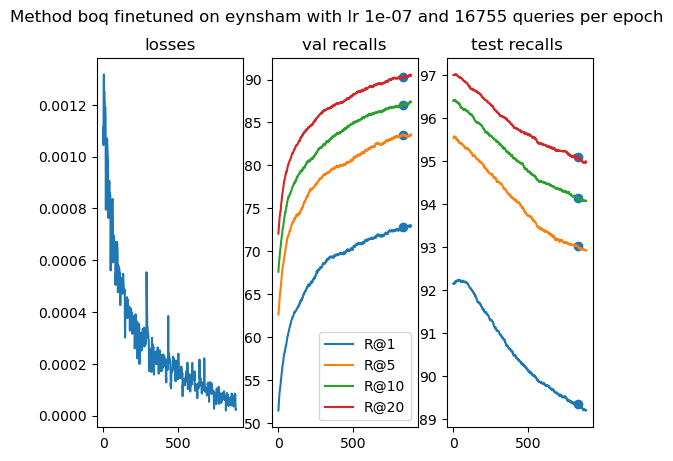

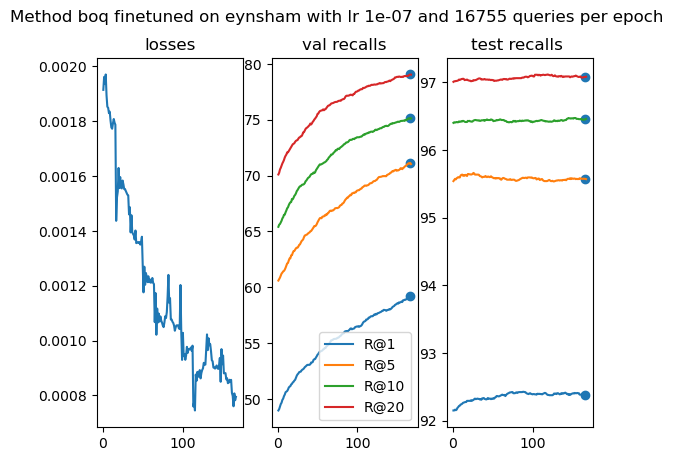

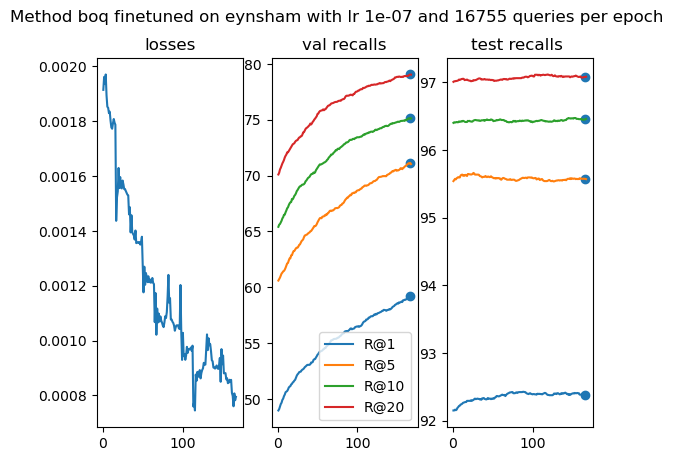

In [220]:
loss1=create_plot("boq",'eynsham',lr=lr,num=10,show_num=show_num,dots=True,patience=patience,print_shizzl=print_shizzl)
loss1=create_plot("boq",'eynsham',lr=lr,num=11,show_num=show_num,dots=True,patience=patience,print_shizzl=print_shizzl)
loss1=create_plot("boq",'eynsham',lr=lr,num=11,show_num=show_num,dots=True,patience=patience,print_shizzl=print_shizzl)


Namespace(datasets_folder='../datasets_vg/datasets', dataset_name='eynsham', method='boq', original_training_data='gsv', num_workers=6, train_batch_size=16, seed=0, infer_batch_size=16, mining='full', lr=1e-07, margin=0.1, criterion='triplet', optim='adam', negs_num_per_query=2, epochs_num=100, log_frequency=1008, ablation=False, ablation_nordland=False, save_models=False, scheduled_lr=False, gamma_lr=0.5, step_lr=10, test_val_queries=0.1, grayscale=False, exact_match=False, resume='', queries_per_epoch=16755, patience=2, test_method='hard_resize', augments=True, create_augments=False, use_val_augments=True, val_save_dir='/home/osverburg/validation', log_dir='../logs', device='cuda', gpu_id='6', pca=False, pca_folder=None, random_vals=False, stop_after_patience=False, val_split=0.3, val_positive_dist_threshold=25, train_positives_dist_threshold=25, backbone='DINOV2', descriptors_dimension=12288, recall_values=[1, 5, 10, 20], no_labels=False, resize=[322, 322], efficient_ram_testing=Fal

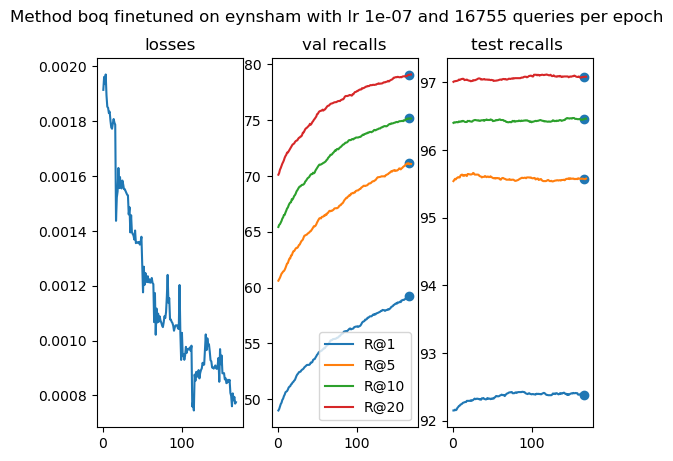

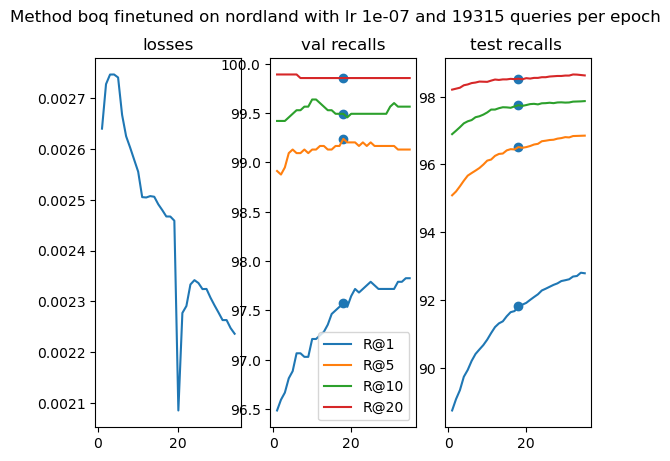

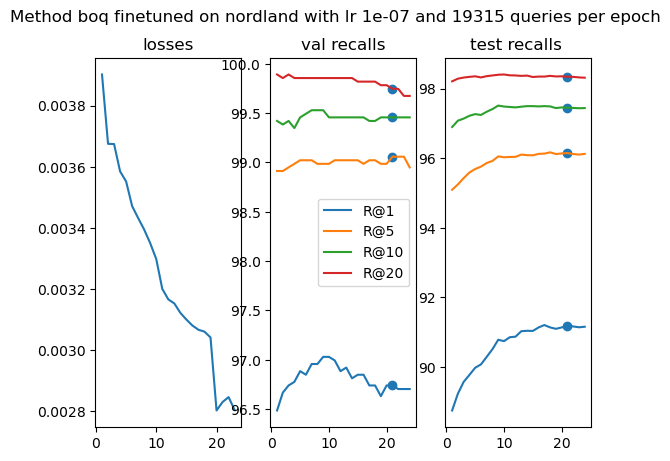

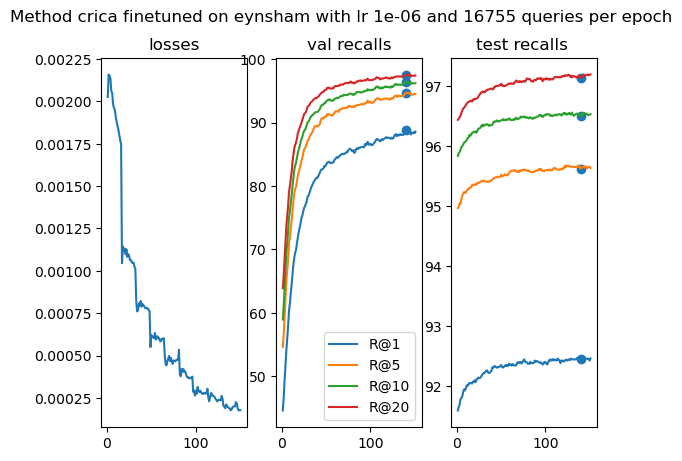

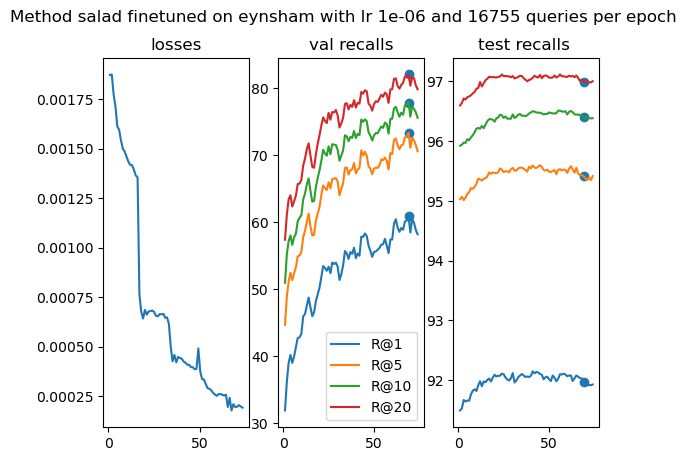

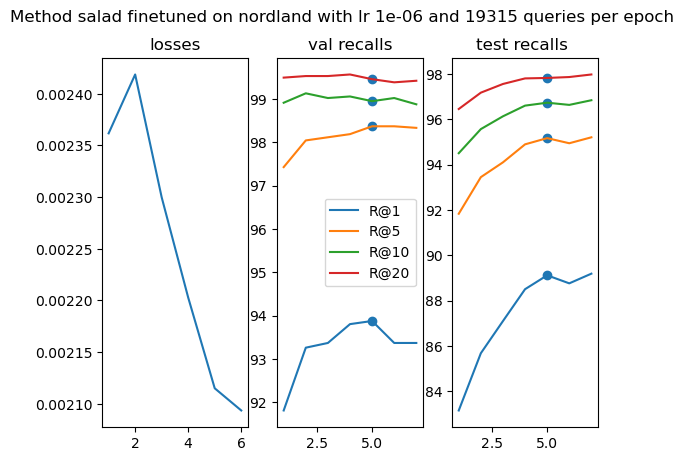

In [227]:
show_num=-1
lr=1e-7
patience=None

print_shizzl=True
# loss1=create_plot("crica",'nordland',lr=1e-6,num=7,show_num=show_num,dots=True,patience=patience,print_shizzl=True)
# loss1=create_plot("boq",'nordland',lr=1e-7,num=5,show_num=show_num,dots=True,patience=patience,print_shizzl=True)
# loss1=create_plot("boq",'nordland',lr=1e-7,num=0,show_num=show_num,dots=True,patience=patience,print_shizzl=True)
# loss1=create_plot("crica",'amstertime',lr=1e-8,num=3,show_num=show_num,dots=True,patience=patience,print_shizzl=True)
# loss1=create_plot("salad",'amstertime',lr=1e-8,num="",show_num=show_num,dots=True,patience=patience,print_shizzl=True)

# loss1=create_plot("salad",'nordland',lr=1e-7,num="1",show_num=show_num,dots=True,patience=patience,print_shizzl=True)
# loss1=create_plot("boq",'eynsham',lr=lr,num=11,show_num=show_num,dots=True,patience=patience,print_shizzl=print_shizzl)
# # loss1=create_plot("crica",'eynsham',lr=1e-6,num="",show_num=show_num,dots=True,patience=patience,print_shizzl=print_shizzl)
# loss1=create_plot("crica",'eynsham',lr=1e-6,num=0,show_num=show_num,dots=True,patience=patience,print_shizzl=print_shizzl)
# # loss1=create_plot("crica",'nordland',lr=1e-6,num=8,show_num=show_num,dots=True,patience=patience,print_shizzl=print_shizzl)
# loss1=create_plot("boq",'nordland',lr=1e-7,num=7,show_num=show_num,dots=True,patience=patience,print_shizzl=print_shizzl)
# loss1=create_plot("boq",'nordland',lr=1e-7,num=8,show_num=show_num,dots=True,patience=patience,print_shizzl=print_shizzl)
# # loss1=create_plot("crica",'nordland',lr=1e-6,num=9,show_num=show_num,dots=True,patience=patience,print_shizzl=print_shizzl)

loss1=create_plot("boq",'eynsham',lr=1e-7,num=11,show_num=show_num,dots=True,patience=patience,print_shizzl=print_shizzl)
loss1=create_plot("boq",'nordland',lr=1e-7,num=9,show_num=show_num,dots=True,patience=patience,print_shizzl=print_shizzl)
loss1=create_plot("boq",'nordland',lr=1e-7,num=10,show_num=show_num,dots=True,patience=patience,print_shizzl=print_shizzl)

loss1=create_plot("crica",'eynsham',lr=1e-6,num="0",show_num=show_num,dots=True,patience=None,print_shizzl=print_shizzl)
# loss1=create_plot("crica",'nordland',lr=1e-6,num="10",show_num=show_num,dots=True,patience=None,print_shizzl=print_shizzl)

loss1=create_plot("salad",'eynsham',lr=1e-6,num="0",show_num=show_num,dots=True,patience=None,print_shizzl=print_shizzl)
loss1=create_plot("salad",'nordland',lr=1e-6,num="1",show_num=show_num,dots=True,patience=None,print_shizzl=print_shizzl)

# loss1=create_plot("salad",'nordland',lr=1e-6,num=0,show_num=show_num,dots=True,patience=patience,print_shizzl=print_shizzl)
# loss1=create_plot("crica",'eynsham',lr=1e-7,num=9,show_num=show_num,dots=True,patience=patience,print_shizzl=print_shizzl)

# # loss1=create_plot("boq",'eynsham',lr=lr,num=5,show_num=show_num,dots=True,patience=patience,print_shizzl=print_shizzl)
# loss1=create_plot("boq",'eynsham',lr=lr,num=6,show_num=show_num,dots=True,patience=patience,print_shizzl=print_shizzl)
# loss1=create_plot("boq",'eynsham',lr=lr,num=8,show_num=show_num,dots=True,patience=patience,print_shizzl=print_shizzl)
# loss1=create_plot("boq",'eynsham',lr=lr,num=10,show_num=show_num,dots=True,patience=patience,print_shizzl=print_shizzl)
# loss1=create_plot("boq",'eynsham',lr=lr,num=1,show_num=show_num,dots=True,patience=patience,print_shizzl=print_shizzl)
# loss1=create_plot("boq",'tokyo247',lr=lr,num="",show_num=show_num,dots=True,patience=patience,print_shizzl=print_shizzl)
# loss1=create_plot("crica",'eynsham',lr=1e-6,num="",show_num=show_num,dots=True,patience=None,print_shizzl=print_shizzl)
# loss1=create_plot("crica",'nordland',lr=1e-6,num="8",show_num=show_num,dots=True,patience=None,print_shizzl=print_shizzl)
# loss1=create_plot("crica",'sped',lr=1e-6,num="0",show_num=show_num,dots=True,patience=None,print_shizzl=print_shizzl)
# loss1=create_plot("crica",'amstertime',lr=1e-6,num=19,show_num=show_num,dots=True,patience=None,print_shizzl=print_shizzl)
# loss1=create_plot("crica",'amstertime',lr=1e-6,num=20,show_num=show_num,dots=True,patience=None,print_shizzl=print_shizzl)
# loss1=create_plot("crica",'sped',lr=1e-6,num=1,show_num=show_num,dots=True,patience=None,print_shizzl=print_shizzl)
# loss1=create_plot("crica",'amstertime',lr=1e-6,num=15,show_num=show_num,dots=True,patience=None,print_shizzl=print_shizzl)
# loss1=create_plot("salad",'nordland',lr=1e-6,num="",show_num=show_num,dots=True,patience=None,print_shizzl=print_shizzl)
# loss1=create_plot("salad",'sped',lr=1e-6,num="0",show_num=show_num,dots=True,patience=None,print_shizzl=print_shizzl)
# loss1=create_plot("salad",'amstertime',lr=1e-6,num=0,show_num=show_num,dots=True,patience=None,print_shizzl=print_shizzl)


Namespace(datasets_folder='../datasets_vg/datasets', dataset_name='nordland', method='boq', original_training_data='gsv', num_workers=6, train_batch_size=16, seed=0, infer_batch_size=16, mining='full', lr=1e-07, margin=0.1, criterion='triplet', optim='adam', negs_num_per_query=2, epochs_num=100, log_frequency=1008, ablation=False, ablation_nordland=False, save_models=True, scheduled_lr=False, gamma_lr=0.5, step_lr=10, test_val_queries=0.1, grayscale=False, exact_match=False, resume='', queries_per_epoch=19315, patience=2, test_method='hard_resize', augments=True, create_augments=False, use_val_augments=True, val_save_dir='/home/osverburg/validation', log_dir='../logs', device='cuda', gpu_id='5', pca=False, pca_folder=None, random_vals=False, stop_after_patience=False, val_split=0.3, val_positive_dist_threshold=25, train_positives_dist_threshold=25, backbone='DINOV2', descriptors_dimension=12288, recall_values=[1, 5, 10, 20], no_labels=False, resize=[322, 322], efficient_ram_testing=Fal

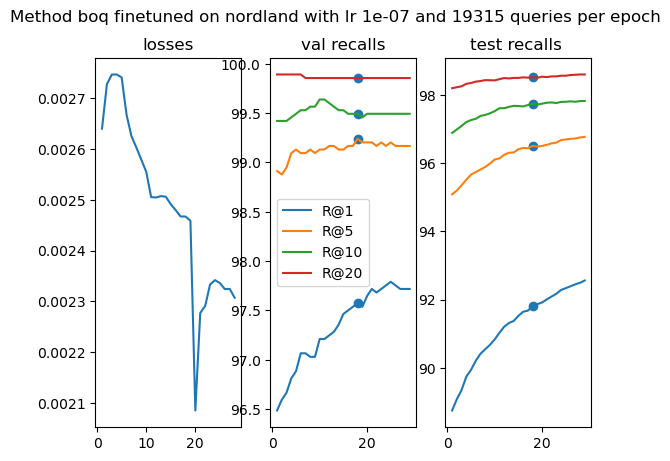

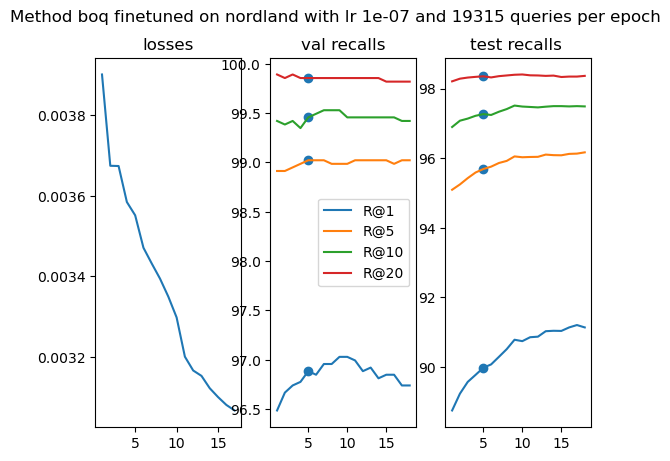

In [203]:
loss1=create_plot("boq",'nordland',lr=lr,num=9,show_num=show_num,dots=True,patience=patience,print_shizzl=print_shizzl)
loss1=create_plot("boq",'nordland',lr=lr,num=10,show_num=show_num,dots=True,patience=patience,print_shizzl=print_shizzl)
# loss1=create_plot("crica",'nordland',lr=1e-6,num=0,show_num=show_num,dots=True,patience=patience,print_shizzl=print_shizzl)
# loss1=create_plot("salad",'nordland',lr=1e-6,num=0,show_num=show_num,dots=True,patience=patience,print_shizzl=print_shizzl)
# 